In [ ]:
!pip install pymatgen mp-api umap-learn imbalanced-learn scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.8/308.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.4/127.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━

Import Library

In [ ]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap

from mp_api.client import MPRester
from pymatgen.analysis.diffraction.xrd import XRDCalculator

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras import layers, models, Model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.manifold import TSNE


CONFIGURATION & SETUP

In [ ]:
# ============================================================================
# CONFIGURATION & SETUP
# ============================================================================

API_KEY = "sMWxUUzNkgFJyEegqotWyVYFJEtK4N7K"
TARGET_SYSTEMS = ["cubic", "monoclinic", "orthorhombic", "tetragonal"]

TWO_THETA_MIN = 10
TWO_THETA_MAX = 110
N_POINTS = 2048
MAX_PER_CLASS = 50000

SEED = 15
EPOCHS_FINAL = 5
BATCH_SIZE = 16

# ISMOTE Parameters
K_NEIGHBORS = 3
MAX_ITERATIONS = 5

# Set seed for reproducibility
def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)
print(f"Seed set to {SEED}")
print(f"Target crystal systems: {TARGET_SYSTEMS}")
print(f"Data Split Ratio - Training:Validation:Testing = 70:10:20")
print(f"Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print(f"Oversampling Method: ISMOTE (Iteration-based SMOTE)")
print(f"ISMOTE Parameters: K={K_NEIGHBORS}, Max Iterations={MAX_ITERATIONS}")

Seed set to 15
Target crystal systems: ['cubic', 'monoclinic', 'orthorhombic', 'tetragonal']
Data Split Ratio - Training:Validation:Testing = 70:10:20
Epochs: 5 (NO Early Stopping)
Oversampling Method: ISMOTE (Iteration-based SMOTE)
ISMOTE Parameters: K=3, Max Iterations=5


DATA LOADING FROM MATERIALS PROJECT

In [ ]:
def load_perovskite_data_from_mp(api_key: str, max_per_class: int = MAX_PER_CLASS):
    """Load perovskite data from Materials Project"""

    data_records = []
    class_counts = {c: 0 for c in TARGET_SYSTEMS}

    with MPRester(api_key) as mpr:
        # Search for perovskite materials
        robo_docs = mpr.materials.robocrys.search(keywords=["perovskite"])
        perov_mpids = [str(doc.material_id) for doc in robo_docs][:50000]

        print(f"Found {len(perov_mpids)} perovskite materials")

        # Get material summaries
        summaries = mpr.materials.summary.search(
            material_ids=perov_mpids,
            fields=["material_id", "structure", "symmetry", "formula_pretty",
                   "density", "volume", "nsites"],
        )

        for doc in summaries:
            sym = getattr(doc, "symmetry", None)
            if sym is None or sym.crystal_system is None:
                continue

            cs_raw = sym.crystal_system
            if hasattr(cs_raw, "value"):
                cs = str(cs_raw.value).lower()
            else:
                cs_str = str(cs_raw)
                if "." in cs_str:
                    cs_str = cs_str.split(".")[-1]
                cs = cs_str.lower()

            if cs not in TARGET_SYSTEMS:
                continue
            if class_counts[cs] >= max_per_class:
                continue

            structure = doc.structure
            if structure is None:
                continue

            # Collect data
            record = {
                'material_id': str(doc.material_id),
                'formula': str(doc.formula_pretty) if hasattr(doc, 'formula_pretty') else None,
                'crystal_system': cs,
                'density': float(doc.density) if hasattr(doc, 'density') else None,
                'volume': float(doc.volume) if hasattr(doc, 'volume') else None,
                'nsites': int(doc.nsites) if hasattr(doc, 'nsites') else None,
                'structure': structure
            }

            data_records.append(record)
            class_counts[cs] += 1

            if all(class_counts[c] >= max_per_class for c in TARGET_SYSTEMS):
                break

    print(f"\nTotal materials collected: {len(data_records)}")
    print(f"Class distribution: {class_counts}")

    return pd.DataFrame(data_records)

# Load data
print("Loading data from Materials Project...")
df_materials = load_perovskite_data_from_mp(API_KEY)
print(f"\nDataset shape: {df_materials.shape}")

Loading data from Materials Project...


Retrieving RobocrystallogapherDoc documents:   0%|          | 0/8509 [00:00<?, ?it/s]

Found 8509 perovskite materials


Retrieving SummaryDoc documents:   0%|          | 0/7886 [00:00<?, ?it/s]


Total materials collected: 7015
Class distribution: {'cubic': 4877, 'monoclinic': 869, 'orthorhombic': 1003, 'tetragonal': 266}

Dataset shape: (7015, 7)


DATA EXPLORATION

In [ ]:
# ============================================================================
# DATA EXPLORATION
# ============================================================================

# Check data types
print("\n" + "="*70)
print("DATA TYPES")
print("="*70)
print(df_materials.dtypes)
print()

# Display columns/features
print("="*70)
print("COLUMNS/FEATURES")
print("="*70)
print(f"Columns: {list(df_materials.columns)}")
print()

# Display top 4 samples (excluding structure column for readability)
print("="*70)
print("TOP 4 SAMPLES (Preview)")
print("="*70)
display_df = df_materials.drop(columns=['structure']).head(4)
print(display_df.to_string())


DATA TYPES
material_id        object
formula            object
crystal_system     object
density           float64
volume            float64
nsites              int64
structure          object
dtype: object

COLUMNS/FEATURES
Columns: ['material_id', 'formula', 'crystal_system', 'density', 'volume', 'nsites', 'structure']

TOP 4 SAMPLES (Preview)
  material_id formula crystal_system   density     volume  nsites
0  mp-1183288  BaInO3          cubic  6.331162  78.721649       5
1  mp-1183286  BaDyO3          cubic  6.651911  86.828787       5
2  mp-1183284  BaLiO3          cubic  4.677365  68.257565       5
3  mp-1183282  BaBeO3          cubic  5.464992  59.049462       5


MISSING VALUES ANALYSIS

In [ ]:
# ============================================================================
# MISSING VALUES ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("MISSING VALUES ANALYSIS")
print("="*70)

missing_data = df_materials.isnull().sum()
missing_percent = (df_materials.isnull().sum() / len(df_materials)) * 100

missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing Count': missing_data.values,
    'Missing Percentage': missing_percent.values
})

print(missing_df.to_string(index=False))

# Visualize missing values only if there are any
if missing_percent.sum() > 0:
    plt.figure(figsize=(10, 6))
    missing_percent[missing_percent > 0].plot(kind='bar', color='coral', edgecolor='black')
    plt.title('Missing Values Percentage by Column', fontweight='bold', fontsize=14)
    plt.xlabel('Column', fontsize=12)
    plt.ylabel('Missing Percentage (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\n⚠ Total missing values: {missing_data.sum()}")
else:
    print("\n" + "="*70)
    print("✓ NO MISSING VALUES FOUND!")
    print("="*70)
    print("All columns are complete. Data quality is excellent!")


MISSING VALUES ANALYSIS
        Column  Missing Count  Missing Percentage
   material_id              0                 0.0
       formula              0                 0.0
crystal_system              0                 0.0
       density              0                 0.0
        volume              0                 0.0
        nsites              0                 0.0
     structure              0                 0.0

✓ NO MISSING VALUES FOUND!
All columns are complete. Data quality is excellent!


CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)


CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)

Count by Crystal System:
crystal_system
cubic           4877
orthorhombic    1003
monoclinic       869
tetragonal       266
Name: count, dtype: int64

Percentage by Crystal System:
  Cubic          :  69.52%
  Orthorhombic   :  14.30%
  Monoclinic     :  12.39%
  Tetragonal     :   3.79%


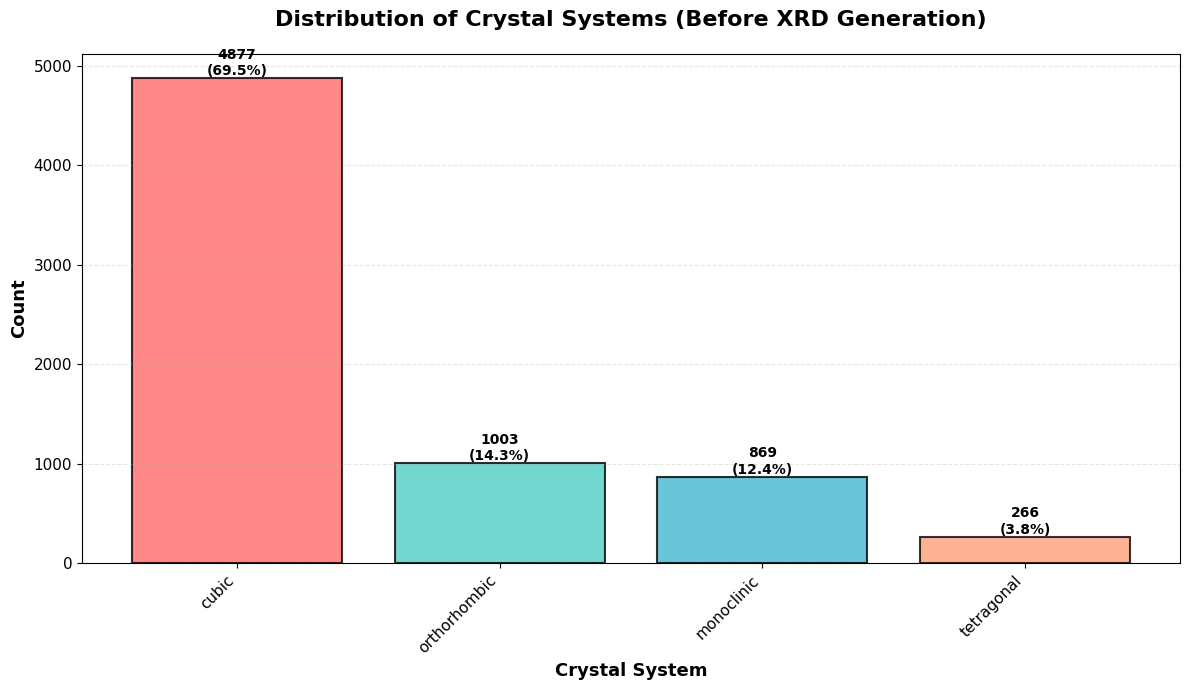

In [ ]:
# ============================================================================
# CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)
# ============================================================================

print("\n" + "="*70)
print("CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)")
print("="*70)

class_distribution = df_materials['crystal_system'].value_counts()
print("\nCount by Crystal System:")
print(class_distribution)

print("\nPercentage by Crystal System:")
class_distribution_pct = (class_distribution / len(df_materials) * 100).round(2)
for system, pct in class_distribution_pct.items():
    print(f"  {system.capitalize():<15}: {pct:>6.2f}%")

# Plot distribution
plt.figure(figsize=(12, 7))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = plt.bar(class_distribution.index, class_distribution.values,
               color=colors[:len(class_distribution)],
               edgecolor='black', linewidth=1.5, alpha=0.8)

plt.title('Distribution of Crystal Systems (Before XRD Generation)',
          fontweight='bold', fontsize=16, pad=20)
plt.xlabel('Crystal System', fontsize=13, fontweight='bold')
plt.ylabel('Count', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(df_materials)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

XRD PATTERN GENERATION

In [ ]:
# ============================================================================
# XRD PATTERN GENERATION
# ============================================================================

def generate_xrd_patterns(df_materials, two_theta_min=TWO_THETA_MIN,
                         two_theta_max=TWO_THETA_MAX, n_points=N_POINTS):
    """Generate XRD patterns from structures"""

    two_theta_grid = np.linspace(two_theta_min, two_theta_max, n_points)
    X_patterns = []
    y_systems = []
    valid_indices = []
    failed_count = 0

    xrd_calc = XRDCalculator(wavelength="CuKa")

    print("="*70)
    print("GENERATING XRD PATTERNS")
    print("="*70)
    print(f"2θ range: {two_theta_min}° - {two_theta_max}°")
    print(f"Number of points: {n_points}")
    print(f"Wavelength: Cu Kα")
    print()

    total = len(df_materials)

    for idx, row in df_materials.iterrows():
        try:
            structure = row['structure']
            pattern = xrd_calc.get_pattern(
                structure,
                two_theta_range=(two_theta_min, two_theta_max),
            )
            intensities = np.interp(two_theta_grid, pattern.x, pattern.y)

            X_patterns.append(intensities)
            y_systems.append(row['crystal_system'])
            valid_indices.append(idx)

        except Exception as e:
            failed_count += 1
            if failed_count <= 3:  # Only show first 3 errors
                print(f"✗ Error for {row['material_id']}: {str(e)[:50]}...")
            continue

        if (len(X_patterns) % 500) == 0:
            print(f"✓ Processed {len(X_patterns)}/{total} patterns... ({len(X_patterns)/total*100:.1f}%)")

    X_patterns = np.array(X_patterns, dtype=np.float32)
    y_systems = np.array(y_systems)

    print()
    print("="*70)
    print("XRD GENERATION SUMMARY")
    print("="*70)
    print(f"✓ Successfully generated: {len(X_patterns)} patterns")
    print(f"✗ Failed: {failed_count} patterns")
    print(f"Success rate: {len(X_patterns)/(len(X_patterns)+failed_count)*100:.2f}%")
    print(f"Pattern shape: {X_patterns.shape}")
    print(f"Crystal system distribution:\n{Counter(y_systems)}")

    return two_theta_grid, X_patterns, y_systems, valid_indices

# Generate XRD patterns
two_theta_grid, X_raw, y_str, valid_idx = generate_xrd_patterns(df_materials)

# Update dataframe to keep only valid materials
df_materials = df_materials.iloc[valid_idx].reset_index(drop=True)

print(f"\n✓ Final dataset size: {len(X_raw)} samples")

GENERATING XRD PATTERNS
2θ range: 10° - 110°
Number of points: 2048
Wavelength: Cu Kα

✓ Processed 500/7015 patterns... (7.1%)
✓ Processed 1000/7015 patterns... (14.3%)
✓ Processed 1500/7015 patterns... (21.4%)
✓ Processed 2000/7015 patterns... (28.5%)
✓ Processed 2500/7015 patterns... (35.6%)
✓ Processed 3000/7015 patterns... (42.8%)
✓ Processed 3500/7015 patterns... (49.9%)
✓ Processed 4000/7015 patterns... (57.0%)
✓ Processed 4500/7015 patterns... (64.1%)
✓ Processed 5000/7015 patterns... (71.3%)
✓ Processed 5500/7015 patterns... (78.4%)
✓ Processed 6000/7015 patterns... (85.5%)
✓ Processed 6500/7015 patterns... (92.7%)
✓ Processed 7000/7015 patterns... (99.8%)

XRD GENERATION SUMMARY
✓ Successfully generated: 7015 patterns
✗ Failed: 0 patterns
Success rate: 100.00%
Pattern shape: (7015, 2048)
Crystal system distribution:
Counter({np.str_('cubic'): 4877, np.str_('orthorhombic'): 1003, np.str_('monoclinic'): 869, np.str_('tetragonal'): 266})

✓ Final dataset size: 7015 samples


XRD PATTERN VISUALIZATION


XRD PATTERN VISUALIZATION
Displaying 1 sample per crystal system (sorted by 2θ)
Plotting Cubic: 4877 samples available
Plotting Monoclinic: 869 samples available
Plotting Orthorhombic: 1003 samples available
Plotting Tetragonal: 266 samples available


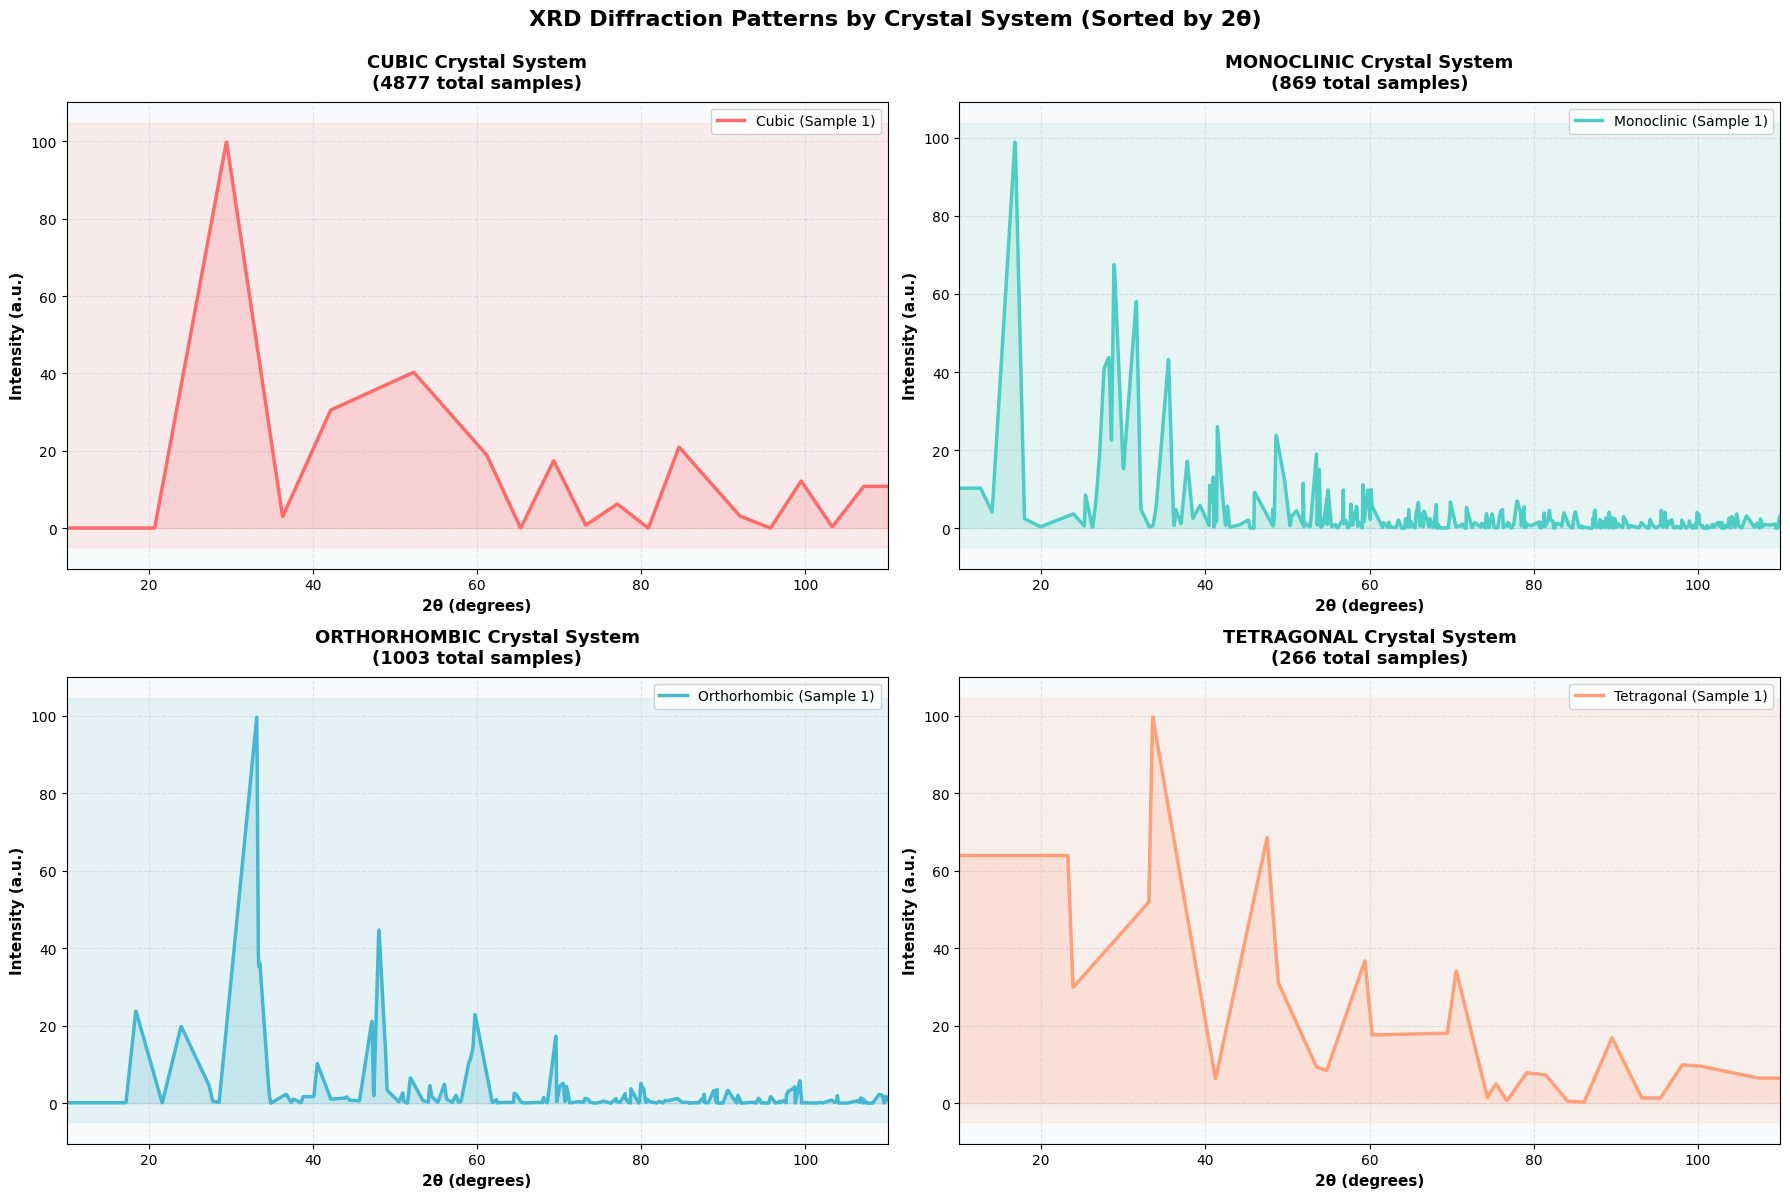


✓ XRD patterns visualization complete!
✓ Each pattern is sorted by 2θ angle


In [ ]:
# ============================================================================
# XRD PATTERN VISUALIZATION
# ============================================================================

print("\n" + "="*70)
print("XRD PATTERN VISUALIZATION")
print("="*70)
print("Displaying 1 sample per crystal system (sorted by 2θ)")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

colors_map = {
    'cubic': '#FF6B6B',
    'monoclinic': '#4ECDC4',
    'orthorhombic': '#45B7D1',
    'tetragonal': '#FFA07A'
}

for idx, system in enumerate(TARGET_SYSTEMS):
    ax = axes[idx]

    # Get indices for this system
    system_indices = np.where(y_str == system)[0]

    print(f"Plotting {system.capitalize()}: {len(system_indices)} samples available")

    if len(system_indices) > 0:
        # Take only 1 sample (first sample)
        sample_idx = system_indices[0]

        # Get pattern data
        pattern_data = X_raw[sample_idx]

        # Sort by 2θ (should already be sorted, but ensuring)
        sorted_indices = np.argsort(two_theta_grid)
        two_theta_sorted = two_theta_grid[sorted_indices]
        pattern_sorted = pattern_data[sorted_indices]

        # Plot the sorted pattern
        ax.plot(two_theta_sorted, pattern_sorted,
               linewidth=2.5,
               color=colors_map[system],
               label=f'{system.capitalize()} (Sample 1)')

        # Fill under the curve for better visualization
        ax.fill_between(two_theta_sorted, pattern_sorted,
                        alpha=0.2, color=colors_map[system])

    ax.set_title(f'{system.upper()} Crystal System\n({len(system_indices)} total samples)',
                fontweight='bold', fontsize=13, pad=10)
    ax.set_xlabel('2θ (degrees)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Intensity (a.u.)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_facecolor('#f8f9fa')

    # Add subtle background color
    ax.axhspan(ax.get_ylim()[0], ax.get_ylim()[1], alpha=0.1, color=colors_map[system])

    # Set x-axis limits
    ax.set_xlim(TWO_THETA_MIN, TWO_THETA_MAX)

plt.suptitle('XRD Diffraction Patterns by Crystal System (Sorted by 2θ)',
            fontweight='bold', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ XRD patterns visualization complete!")
print("✓ Each pattern is sorted by 2θ angle")

DATA PREPARATION: ENCODING & SPLITTING (70:10:20)

In [ ]:
# ============================================================================
# DATA PREPARATION: ENCODING & SPLITTING (70:10:20)
# ============================================================================

print("\n" + "="*70)
print("DATA PREPARATION: ENCODING & SPLITTING")
print("="*70)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_str)
class_names = list(le.classes_)

print("\nClass Encoding Mapping:")
for i, name in enumerate(class_names):
    count = np.sum(y_encoded == i)
    print(f"  {i} → {name.capitalize():<15} ({count} samples)")

# Split data: 70% train, 10% validation, 20% test
# First split: 80% (train+val), 20% test
X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X_raw, y_encoded,
    test_size=0.20,
    random_state=SEED,
    stratify=y_encoded
)

# Second split: 70% train, 10% validation (from the 80%)
# 10/80 = 0.125
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.125,
    random_state=SEED,
    stratify=y_temp
)

print("\n" + "-"*70)
print("DATA SPLIT (70% Train / 10% Validation / 20% Test)")
print("-"*70)
print(f"Training set size:     {len(X_train_raw):>6} samples ({len(X_train_raw)/len(X_raw)*100:.1f}%)")
print(f"Validation set size:   {len(X_val_raw):>6} samples ({len(X_val_raw)/len(X_raw)*100:.1f}%)")
print(f"Test set size:         {len(X_test_raw):>6} samples ({len(X_test_raw)/len(X_raw)*100:.1f}%)")
print(f"Total:                 {len(X_raw):>6} samples")

print("\nTraining Set Distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_train == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples ({count/len(y_train)*100:>5.1f}%)")

print("\nValidation Set Distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_val == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples ({count/len(y_val)*100:>5.1f}%)")

print("\nTest Set Distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_test == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples ({count/len(y_test)*100:>5.1f}%)")


DATA PREPARATION: ENCODING & SPLITTING

Class Encoding Mapping:
  0 → Cubic           (4877 samples)
  1 → Monoclinic      (869 samples)
  2 → Orthorhombic    (1003 samples)
  3 → Tetragonal      (266 samples)

----------------------------------------------------------------------
DATA SPLIT (70% Train / 10% Validation / 20% Test)
----------------------------------------------------------------------
Training set size:       4910 samples (70.0%)
Validation set size:      702 samples (10.0%)
Test set size:           1403 samples (20.0%)
Total:                   7015 samples

Training Set Distribution:
  Cubic          :  3414 samples ( 69.5%)
  Monoclinic     :   608 samples ( 12.4%)
  Orthorhombic   :   702 samples ( 14.3%)
  Tetragonal     :   186 samples (  3.8%)

Validation Set Distribution:
  Cubic          :   488 samples ( 69.5%)
  Monoclinic     :    87 samples ( 12.4%)
  Orthorhombic   :   100 samples ( 14.2%)
  Tetragonal     :    27 samples (  3.8%)

Test Set Distribution:
 

ISMOTE IMPLEMENTATION (Iteration-based SMOTE)

In [ ]:
# ============================================================================
# ISMOTE IMPLEMENTATION (Iteration-based SMOTE)
# ============================================================================

from sklearn.neighbors import NearestNeighbors

class ISMOTE:
    """
    Iteration-based Synthetic Minority Over-sampling Technique (ISMOTE)
    Based on: Song & Liu (2024) - Neural Processing Letters
    """

    def __init__(self, k_neighbors=5, max_iterations=10, random_state=42):
        """
        Initialize ISMOTE

        Parameters:
        -----------
        k_neighbors : int
            Number of nearest neighbors to use
        max_iterations : int
            Maximum number of iterations
        random_state : int
            Random seed for reproducibility
        """
        self.k_neighbors = k_neighbors
        self.max_iterations = max_iterations
        self.random_state = random_state
        np.random.seed(random_state)

    def fit_resample(self, X, y, classifier_builder):
        """
        Perform ISMOTE oversampling

        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Training data
        y : array-like, shape (n_samples,)
            Target labels
        classifier_builder : function
            Function that builds and returns a compiled classifier

        Returns:
        --------
        X_resampled : array-like
            Resampled training data
        y_resampled : array-like
            Resampled target labels
        """
        X_current = X.copy()
        y_current = y.copy()

        # Get class distribution
        unique_classes, class_counts = np.unique(y, return_counts=True)
        majority_count = class_counts.max()

        print("\n" + "="*70)
        print("ISMOTE: ITERATION-BASED SMOTE")
        print("="*70)
        print(f"K-neighbors: {self.k_neighbors}")
        print(f"Max iterations: {self.max_iterations}")
        print(f"\nInitial class distribution:")
        for cls, count in zip(unique_classes, class_counts):
            print(f"  Class {cls}: {count} samples")

        iteration = 0
        while iteration < self.max_iterations:
            print(f"\n--- Iteration {iteration + 1}/{self.max_iterations} ---")

            # Check termination condition
            unique_classes, class_counts = np.unique(y_current, return_counts=True)
            if len(np.unique(class_counts)) == 1:
                print("✓ All classes balanced. Terminating.")
                break

            # Step 1: Pre-training
            print("  Step 1: Pre-training classifier...")
            model = classifier_builder()

            # Prepare data for training
            X_temp = X_current[..., np.newaxis] if len(X_current.shape) == 2 else X_current

            model.fit(X_temp, y_current, epochs=5, batch_size=32, verbose=0)

            # Get predictions
            y_pred = np.argmax(model.predict(X_temp, verbose=0), axis=1)

            # Step 2: Error Set Construction
            print("  Step 2: Constructing error set...")
            error_mask = (y_pred != y_current)
            X_errors = X_current[error_mask]
            y_errors = y_current[error_mask]

            if len(X_errors) == 0:
                print("  No errors found. Terminating.")
                break

            print(f"  Found {len(X_errors)} misclassified samples")

            # Step 3: Error Set Classification (Safe vs Noise)
            print("  Step 3: Classifying errors (safe vs noise)...")
            safe_data_X = []
            safe_data_y = []

            # Fit k-nearest neighbors on all data
            nbrs = NearestNeighbors(n_neighbors=self.k_neighbors + 1)
            nbrs.fit(X_current)

            for i, (x_error, y_error) in enumerate(zip(X_errors, y_errors)):
                # Find K nearest neighbors
                distances, indices = nbrs.kneighbors([x_error])
                neighbor_indices = indices[0][1:]  # Exclude the point itself

                neighbor_labels = y_current[neighbor_indices]

                # Count minority and majority neighbors
                n_same_class = np.sum(neighbor_labels == y_error)
                n_diff_class = len(neighbor_labels) - n_same_class

                # Classify as safe or noise based on neighbors
                # Safe: if error is minority class and surrounded by majority
                # Safe: if error is minority class and has some same class neighbors
                is_minority = class_counts[y_error] < majority_count

                if is_minority:
                    # For minority class errors, consider as safe
                    safe_data_X.append(x_error)
                    safe_data_y.append(y_error)
                else:
                    # For majority class errors, only if surrounded by minority
                    if n_diff_class > n_same_class:
                        safe_data_X.append(x_error)
                        safe_data_y.append(y_error)

            if len(safe_data_X) == 0:
                print("  No safe error data found. Terminating.")
                break

            print(f"  Identified {len(safe_data_X)} safe error samples")

            # Step 4: Generate New Samples
            print("  Step 4: Generating new samples...")
            X_new = []
            y_new = []

            for x_safe, y_safe in zip(safe_data_X, safe_data_y):
                # Find K nearest neighbors of same class
                same_class_mask = (y_current == y_safe)
                X_same_class = X_current[same_class_mask]

                if len(X_same_class) < 2:
                    continue

                # Fit KNN on same class
                nbrs_same = NearestNeighbors(n_neighbors=min(self.k_neighbors, len(X_same_class)))
                nbrs_same.fit(X_same_class)
                distances, indices = nbrs_same.kneighbors([x_safe])

                # Randomly select one neighbor
                neighbor_idx = np.random.choice(indices[0][1:])
                x_neighbor = X_same_class[neighbor_idx]

                # Generate new sample
                r = np.random.random()
                x_new_sample = x_safe + r * (x_neighbor - x_safe)

                X_new.append(x_new_sample)
                y_new.append(y_safe)

            if len(X_new) == 0:
                print("  No new samples generated. Terminating.")
                break

            print(f"  Generated {len(X_new)} new synthetic samples")

            # Add new samples to dataset
            X_current = np.vstack([X_current, X_new])
            y_current = np.hstack([y_current, y_new])

            # Clear model
            tf.keras.backend.clear_session()
            del model

            iteration += 1

        print("\n" + "="*70)
        print("ISMOTE COMPLETED")
        print("="*70)
        unique_classes, class_counts = np.unique(y_current, return_counts=True)
        print("Final class distribution:")
        for cls, count in zip(unique_classes, class_counts):
            print(f"  Class {cls}: {count} samples")

        return X_current, y_current

print("✓ ISMOTE class defined successfully!")

✓ ISMOTE class defined successfully!


APPLYING ISMOTE OVERSAMPLING (TRAINING DATA ONLY)

In [ ]:
# ============================================================================
# APPLYING ISMOTE OVERSAMPLING (TRAINING DATA ONLY)
# ============================================================================

def build_temp_classifier():
    """Build a temporary classifier for ISMOTE"""
    inputs = layers.Input(shape=(X_train_raw.shape[1], 1))
    x = layers.Conv1D(filters=64, kernel_size=50, strides=5, activation="relu", padding="same")(inputs)
    x = layers.AveragePooling1D(pool_size=2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(len(class_names), activation="softmax")(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

print("\n" + "="*70)
print("APPLYING ISMOTE OVERSAMPLING (TRAINING DATA ONLY)")
print("="*70)

print("\nBEFORE ISMOTE:")
print("-" * 50)
print(f"Training samples: {len(X_train_raw)}")
print("\nClass distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_train == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples")

# Apply ISMOTE
ismote = ISMOTE(k_neighbors=K_NEIGHBORS, max_iterations=MAX_ITERATIONS, random_state=SEED)
X_train_ismote, y_train_ismote = ismote.fit_resample(X_train_raw, y_train, build_temp_classifier)

print("\n" + "="*70)
print("AFTER ISMOTE:")
print("-" * 50)
print(f"Training samples: {len(X_train_ismote)} (increased by {len(X_train_ismote) - len(X_train_raw)})")
print("\nClass distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_train_ismote == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples")

print("\n" + "="*70)
print("VALIDATION SET (UNCHANGED - NO OVERSAMPLING):")
print("-" * 50)
print(f"Validation samples: {len(X_val_raw)}")
print("\nClass distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_val == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples")

print("\n" + "="*70)
print("TEST SET (UNCHANGED - NO OVERSAMPLING):")
print("-" * 50)
print(f"Test samples: {len(X_test_raw)}")
print("\nClass distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_test == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples")

print("\n✓ ISMOTE oversampling applied successfully!")


APPLYING ISMOTE OVERSAMPLING (TRAINING DATA ONLY)

BEFORE ISMOTE:
--------------------------------------------------
Training samples: 4910

Class distribution:
  Cubic          :  3414 samples
  Monoclinic     :   608 samples
  Orthorhombic   :   702 samples
  Tetragonal     :   186 samples

ISMOTE: ITERATION-BASED SMOTE
K-neighbors: 3
Max iterations: 5

Initial class distribution:
  Class 0: 3414 samples
  Class 1: 608 samples
  Class 2: 702 samples
  Class 3: 186 samples

--- Iteration 1/5 ---
  Step 1: Pre-training classifier...
  Step 2: Constructing error set...
  Found 244 misclassified samples
  Step 3: Classifying errors (safe vs noise)...
  Identified 242 safe error samples
  Step 4: Generating new samples...
  Generated 242 new synthetic samples

--- Iteration 2/5 ---
  Step 1: Pre-training classifier...
  Step 2: Constructing error set...
  Found 438 misclassified samples
  Step 3: Classifying errors (safe vs noise)...
  Identified 421 safe error samples
  Step 4: Generati

VISUALIZE CLASS DISTRIBUTION COMPARISON

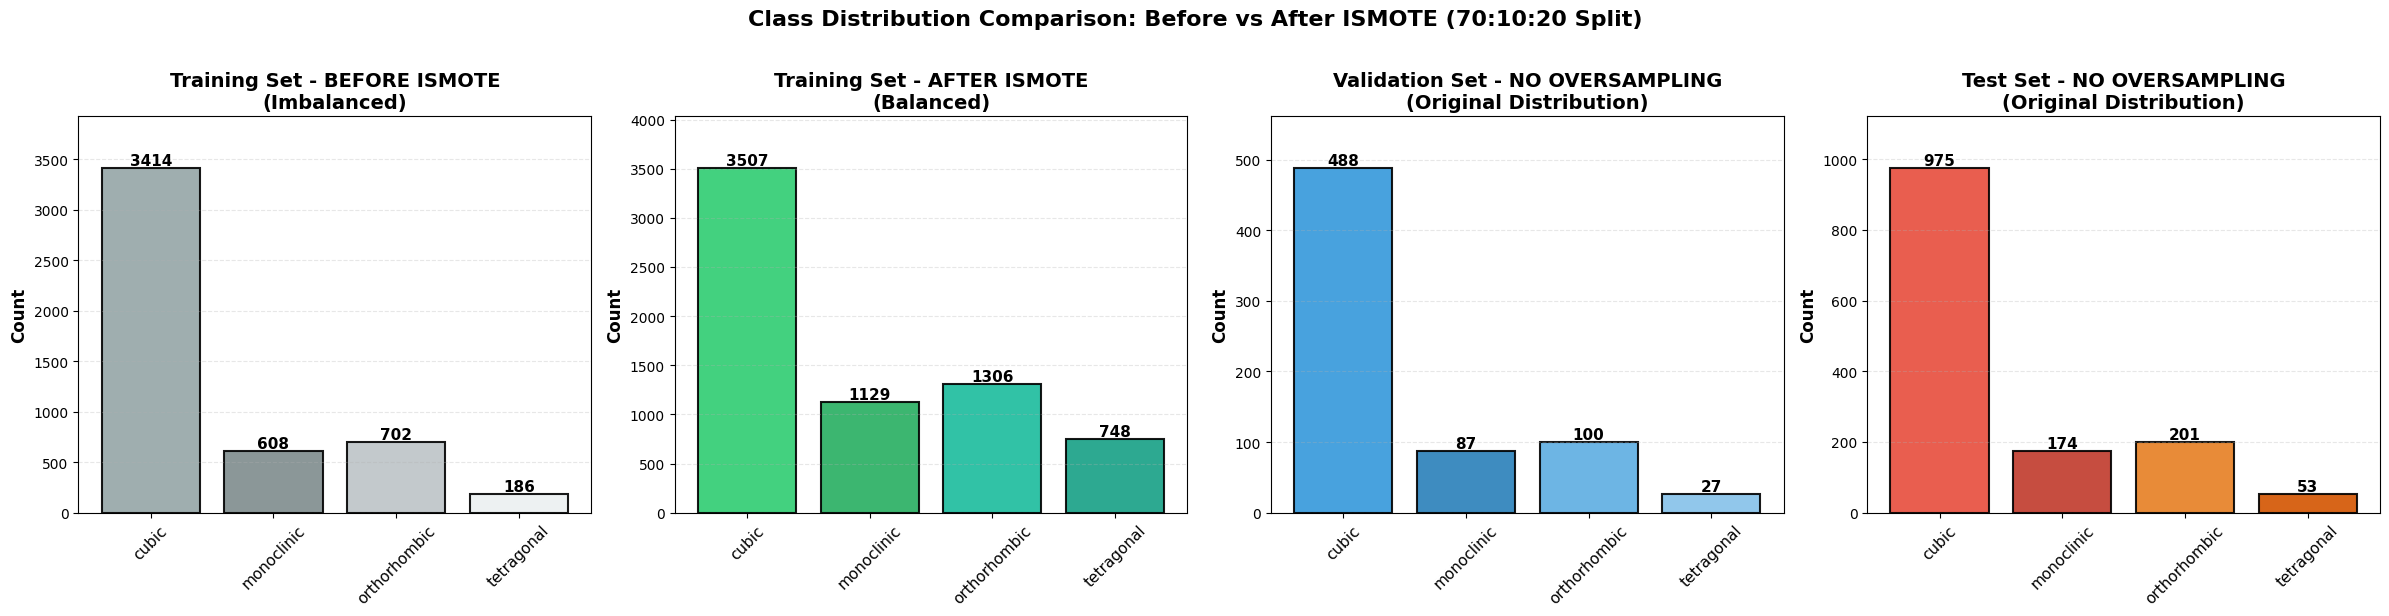

In [ ]:
# ============================================================================
# VISUALIZE CLASS DISTRIBUTION COMPARISON
# ============================================================================

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Color palettes
colors_before = ['#95a5a6', '#7f8c8d', '#bdc3c7', '#ecf0f1']
colors_after = ['#2ecc71', '#27ae60', '#1abc9c', '#16a085']
colors_val = ['#3498db', '#2980b9', '#5dade2', '#85c1e9']
colors_test = ['#e74c3c', '#c0392b', '#e67e22', '#d35400']

# Plot 1: Training Before ISMOTE
unique, counts = np.unique(y_train, return_counts=True)
labels = [class_names[i] for i in unique]
bars1 = axes[0].bar(labels, counts, color=colors_before, edgecolor='black', linewidth=1.5, alpha=0.9)
axes[0].set_title('Training Set - BEFORE ISMOTE\n(Imbalanced)', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars1, counts):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 2: Training After ISMOTE
unique, counts = np.unique(y_train_ismote, return_counts=True)
labels = [class_names[i] for i in unique]
bars2 = axes[1].bar(labels, counts, color=colors_after, edgecolor='black', linewidth=1.5, alpha=0.9)
axes[1].set_title('Training Set - AFTER ISMOTE\n(Balanced)', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=11)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars2, counts):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 3: Validation Set
unique, counts = np.unique(y_val, return_counts=True)
labels = [class_names[i] for i in unique]
bars3 = axes[2].bar(labels, counts, color=colors_val, edgecolor='black', linewidth=1.5, alpha=0.9)
axes[2].set_title('Validation Set - NO OVERSAMPLING\n(Original Distribution)', fontweight='bold', fontsize=14)
axes[2].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45, labelsize=11)
axes[2].grid(axis='y', alpha=0.3, linestyle='--')
axes[2].set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars3, counts):
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 4: Test Set
unique, counts = np.unique(y_test, return_counts=True)
labels = [class_names[i] for i in unique]
bars4 = axes[3].bar(labels, counts, color=colors_test, edgecolor='black', linewidth=1.5, alpha=0.9)
axes[3].set_title('Test Set - NO OVERSAMPLING\n(Original Distribution)', fontweight='bold', fontsize=14)
axes[3].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[3].tick_params(axis='x', rotation=45, labelsize=11)
axes[3].grid(axis='y', alpha=0.3, linestyle='--')
axes[3].set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars4, counts):
    height = bar.get_height()
    axes[3].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle('Class Distribution Comparison: Before vs After ISMOTE (70:10:20 Split)',
            fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

SUMMARY TABLE

In [ ]:
# ============================================================================
# SUMMARY TABLE
# ============================================================================

print("\n" + "="*70)
print("SAMPLE COUNTS SUMMARY TABLE")
print("="*70)

summary_data = []
total_train_before = 0
total_train_after = 0
total_val = 0
total_test = 0

for i, system in enumerate(class_names):
    train_before = np.sum(y_train == i)
    train_after = np.sum(y_train_ismote == i)
    val_count = np.sum(y_val == i)
    test_count = np.sum(y_test == i)

    total_train_before += train_before
    total_train_after += train_after
    total_val += val_count
    total_test += test_count

    increase = train_after - train_before
    increase_pct = (increase / train_before * 100) if train_before > 0 else 0

    summary_data.append({
        'Crystal System': system.capitalize(),
        'Train (Before)': train_before,
        'Train (After)': train_after,
        'Increase': f'+{increase}',
        'Increase %': f'+{increase_pct:.1f}%',
        'Validation': val_count,
        'Test': test_count
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "-"*70)
print(f"{'TOTAL':<20} {total_train_before:>13} {total_train_after:>14} {f'+{total_train_after-total_train_before}':>10} {f'+{(total_train_after-total_train_before)/total_train_before*100:.1f}%':>12} {total_val:>12} {total_test:>6}")
print("="*70)

print(f"\n✓ ISMOTE oversampling increased training samples by {(total_train_after - total_train_before) / total_train_before * 100:.1f}%")


SAMPLE COUNTS SUMMARY TABLE
Crystal System  Train (Before)  Train (After) Increase Increase %  Validation  Test
         Cubic            3414           3507      +93      +2.7%         488   975
    Monoclinic             608           1129     +521     +85.7%          87   174
  Orthorhombic             702           1306     +604     +86.0%         100   201
    Tetragonal             186            748     +562    +302.2%          27    53

----------------------------------------------------------------------
TOTAL                         4910           6690      +1780       +36.3%          702   1403

✓ ISMOTE oversampling increased training samples by 36.3%


MODEL ARCHITECTURE DEFINITIONS

In [ ]:
# ============================================================================
# MODEL ARCHITECTURE DEFINITIONS
# ============================================================================

def build_cnn_fixed(input_shape, num_classes: int):
    """
    Build CNN with fixed architecture
    - 3 Conv1D layers: filters=80, kernel_size=[100, 80, 20], stride=5
    - Average Pooling after each conv layer
    - 2 Fully Connected layers with 30% Dropout
    """
    inputs = layers.Input(shape=input_shape)

    # Convolutional Layer 1: 80 filters, kernel_size=100, stride=5
    x = layers.Conv1D(filters=80, kernel_size=100, strides=5,
                      activation="relu", padding="same",
                      name="conv1")(inputs)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool1")(x)

    # Convolutional Layer 2: 80 filters, kernel_size=80, stride=5
    x = layers.Conv1D(filters=80, kernel_size=80, strides=5,
                      activation="relu", padding="same",
                      name="conv2")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool2")(x)

    # Convolutional Layer 3: 80 filters, kernel_size=20, stride=5
    x = layers.Conv1D(filters=80, kernel_size=20, strides=5,
                      activation="relu", padding="same",
                      name="conv3")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool3")(x)

    # Flatten
    x = layers.Flatten()(x)

    # Fully Connected Layer 1 with Dropout 30%
    x = layers.Dense(128, activation="relu", name="fc1")(x)
    x = layers.Dropout(0.3, name="dropout1")(x)

    # Fully Connected Layer 2 (Feature Layer) with Dropout 30%
    x = layers.Dense(64, activation="relu", name="feature_layer")(x)
    x = layers.Dropout(0.3, name="dropout2")(x)

    # Output Layer
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = models.Model(inputs, outputs, name="CNN_Fixed")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


def build_cnn_woa(params, input_shape, num_classes):
    """
    Build CNN with WOA-optimized hyperparameters
    Architecture:
    - 3 Conv1D layers: all with kernel_size optimized, stride=5
    - Average Pooling after each conv layer
    - 2 Fully Connected layers with 30% Dropout

    WOA optimizes:
    - Number of filters for all 3 conv layers (same value)
    - Fully connected layer 1 units
    - Fully connected layer 2 units (feature layer)
    """
    num_filters = int(params[0])      # Filters for all 3 conv layers
    fc1_units = int(params[1])        # FC layer 1 units
    fc2_units = int(params[2])        # FC layer 2 units (feature layer)

    inputs = layers.Input(shape=input_shape)

    # Convolutional Layer 1: kernel_size=100, stride=5
    x = layers.Conv1D(filters=num_filters, kernel_size=100, strides=5,
                      activation="relu", padding="same",
                      name="conv1")(inputs)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool1")(x)

    # Convolutional Layer 2: kernel_size=80, stride=5
    x = layers.Conv1D(filters=num_filters, kernel_size=80, strides=5,
                      activation="relu", padding="same",
                      name="conv2")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool2")(x)

    # Convolutional Layer 3: kernel_size=20, stride=5
    x = layers.Conv1D(filters=num_filters, kernel_size=20, strides=5,
                      activation="relu", padding="same",
                      name="conv3")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool3")(x)

    # Flatten
    x = layers.Flatten()(x)

    # Fully Connected Layer 1 with Dropout 30%
    x = layers.Dense(fc1_units, activation="relu", name="fc1")(x)
    x = layers.Dropout(0.3, name="dropout1")(x)

    # Fully Connected Layer 2 (Feature Layer) with Dropout 30%
    x = layers.Dense(fc2_units, activation="relu", name="feature_layer")(x)
    x = layers.Dropout(0.3, name="dropout2")(x)

    # Output Layer
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = models.Model(inputs, outputs, name="CNN_WOA")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

PREPARE DATA FOR TRAINING

In [ ]:
# ============================================================================
# PREPARE DATA FOR TRAINING
# ============================================================================

# Reshape data for CNN (add channel dimension)
X_train_no_ismote = X_train_raw[..., np.newaxis]
X_train_with_ismote = X_train_ismote[..., np.newaxis]
X_val = X_val_raw[..., np.newaxis]
X_test = X_test_raw[..., np.newaxis]

print("\n" + "="*70)
print("DATA SHAPES FOR TRAINING")
print("="*70)
print(f"X_train (no ISMOTE):   {X_train_no_ismote.shape}")
print(f"X_train (with ISMOTE): {X_train_with_ismote.shape}")
print(f"X_val:                 {X_val.shape}")
print(f"X_test:                {X_test.shape}")
print("\n✓ All data ready for training!")


DATA SHAPES FOR TRAINING
X_train (no ISMOTE):   (4910, 2048, 1)
X_train (with ISMOTE): (6690, 2048, 1)
X_val:                 (702, 2048, 1)
X_test:                (1403, 2048, 1)

✓ All data ready for training!


TRAIN MODEL 1: CNN WITHOUT ISMOTE

In [ ]:
# ============================================================================
# TRAIN MODEL 1: CNN WITHOUT ISMOTE
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 1: CNN (WITHOUT ISMOTE)")
print("="*70)

print("\nARCHITECTURE SPECIFICATIONS:")
print("-" * 70)
print("• 3 Convolutional Layers:")
print("  - Conv1: 80 filters, kernel=100, stride=5")
print("  - Conv2: 80 filters, kernel=80,  stride=5")
print("  - Conv3: 80 filters, kernel=20,  stride=5")
print("• Pooling: Average Pooling (pool_size=2)")
print("• Fully Connected: 2 layers (128 → 64)")
print("• Dropout: 30% after each FC layer")
print("• Training Data: WITHOUT ISMOTE (Imbalanced)")
print(f"• Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print("-" * 70)

model_cnn_no_ismote = build_cnn_fixed(X_train_no_ismote.shape[1:], num_classes=len(class_names))
model_cnn_no_ismote.summary()

# Train model WITHOUT early stopping
history_cnn_no_ismote = model_cnn_no_ismote.fit(
    X_train_no_ismote, y_train,
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

print("\n✓ CNN Model (No ISMOTE) training complete!")


TRAINING MODEL 1: CNN (WITHOUT ISMOTE)

ARCHITECTURE SPECIFICATIONS:
----------------------------------------------------------------------
• 3 Convolutional Layers:
  - Conv1: 80 filters, kernel=100, stride=5
  - Conv2: 80 filters, kernel=80,  stride=5
  - Conv3: 80 filters, kernel=20,  stride=5
• Pooling: Average Pooling (pool_size=2)
• Fully Connected: 2 layers (128 → 64)
• Dropout: 30% after each FC layer
• Training Data: WITHOUT ISMOTE (Imbalanced)
• Epochs: 5 (NO Early Stopping)
----------------------------------------------------------------------


Model: "CNN_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 80)        │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 80)         │       512,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 80)          │       128,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 80)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 677,364 (2.58 MB)

 Trainable params: 677,364 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.7514 - loss: 0.6394 - val_accuracy: 0.8732 - val_loss: 0.3843
Epoch 2/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8613 - loss: 0.3870 - val_accuracy: 0.8789 - val_loss: 0.2959
Epoch 3/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8832 - loss: 0.2978 - val_accuracy: 0.9088 - val_loss: 0.2554
Epoch 4/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8931 - loss: 0.2739 - val_accuracy: 0.9046 - val_loss: 0.2441
Epoch 5/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9111 - loss: 0.2500 - val_accuracy: 0.9031 - val_loss: 0.2406

✓ CNN Model (No ISMOTE) training complete!


TRAIN MODEL 2: CNN WITH ISMOTE

In [ ]:
# ============================================================================
# TRAIN MODEL 2: CNN WITH ISMOTE
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 2: CNN (WITH ISMOTE)")
print("="*70)

print("\nARCHITECTURE SPECIFICATIONS:")
print("-" * 70)
print("• 3 Convolutional Layers:")
print("  - Conv1: 80 filters, kernel=100, stride=5")
print("  - Conv2: 80 filters, kernel=80,  stride=5")
print("  - Conv3: 80 filters, kernel=20,  stride=5")
print("• Pooling: Average Pooling (pool_size=2)")
print("• Fully Connected: 2 layers (128 → 64)")
print("• Dropout: 30% after each FC layer")
print("• Training Data: WITH ISMOTE (Balanced)")
print(f"• Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print("-" * 70)

model_cnn_with_ismote = build_cnn_fixed(X_train_with_ismote.shape[1:], num_classes=len(class_names))
model_cnn_with_ismote.summary()

# Train model WITHOUT early stopping
history_cnn_with_ismote = model_cnn_with_ismote.fit(
    X_train_with_ismote, y_train_ismote,
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

print("\n✓ CNN Model (With ISMOTE) training complete!")


TRAINING MODEL 2: CNN (WITH ISMOTE)

ARCHITECTURE SPECIFICATIONS:
----------------------------------------------------------------------
• 3 Convolutional Layers:
  - Conv1: 80 filters, kernel=100, stride=5
  - Conv2: 80 filters, kernel=80,  stride=5
  - Conv3: 80 filters, kernel=20,  stride=5
• Pooling: Average Pooling (pool_size=2)
• Fully Connected: 2 layers (128 → 64)
• Dropout: 30% after each FC layer
• Training Data: WITH ISMOTE (Balanced)
• Epochs: 5 (NO Early Stopping)
----------------------------------------------------------------------


Model: "CNN_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 80)        │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 80)         │       512,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 80)          │       128,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 80)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 677,364 (2.58 MB)

 Trainable params: 677,364 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.5790 - loss: 1.0152 - val_accuracy: 0.8020 - val_loss: 0.4407
Epoch 2/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7060 - loss: 0.6216 - val_accuracy: 0.8533 - val_loss: 0.3289
Epoch 3/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7734 - loss: 0.5037 - val_accuracy: 0.8504 - val_loss: 0.3525
Epoch 4/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8318 - loss: 0.4094 - val_accuracy: 0.8889 - val_loss: 0.2912
Epoch 5/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8714 - loss: 0.3147 - val_accuracy: 0.8932 - val_loss: 0.3246

✓ CNN Model (With ISMOTE) training complete!


WHALE OPTIMIZATION ALGORITHM

In [ ]:
# ============================================================================
# WHALE OPTIMIZATION ALGORITHM
# ============================================================================

class WhaleOptimization:
    def __init__(self, n_whales, n_iterations, bounds):
        self.n_whales = n_whales
        self.n_iterations = n_iterations
        self.bounds = bounds
        self.dim = len(bounds)

    def initialize_population(self):
        """Initialize whale positions randomly within bounds"""
        population = np.zeros((self.n_whales, self.dim))
        for i in range(self.dim):
            population[:, i] = np.random.uniform(
                self.bounds[i][0],
                self.bounds[i][1],
                self.n_whales
            )
        return population

    def optimize(self, fitness_function):
        """Run WOA optimization"""
        # Initialize
        population = self.initialize_population()
        fitness = np.array([fitness_function(ind) for ind in population])

        # Best solution
        best_idx = np.argmax(fitness)
        best_position = population[best_idx].copy()
        best_fitness = fitness[best_idx]

        fitness_history = [best_fitness]

        print(f"Initial best fitness: {best_fitness:.4f}")

        # Optimization loop
        for iteration in range(self.n_iterations):
            a = 2 - iteration * (2 / self.n_iterations)  # Decreases from 2 to 0

            for i in range(self.n_whales):
                r1 = np.random.random()
                r2 = np.random.random()

                A = 2 * a * r1 - a
                C = 2 * r2

                p = np.random.random()

                if p < 0.5:
                    if abs(A) < 1:
                        # Encircling prey
                        D = abs(C * best_position - population[i])
                        population[i] = best_position - A * D
                    else:
                        # Search for prey (exploration)
                        rand_idx = np.random.randint(0, self.n_whales)
                        rand_whale = population[rand_idx]
                        D = abs(C * rand_whale - population[i])
                        population[i] = rand_whale - A * D
                else:
                    # Spiral updating position
                    D_prime = abs(best_position - population[i])
                    l = np.random.uniform(-1, 1)
                    population[i] = D_prime * np.exp(l) * np.cos(2 * np.pi * l) + best_position

                # Boundary check
                for j in range(self.dim):
                    population[i, j] = np.clip(
                        population[i, j],
                        self.bounds[j][0],
                        self.bounds[j][1]
                    )

            # Update fitness
            fitness = np.array([fitness_function(ind) for ind in population])

            # Update best
            current_best_idx = np.argmax(fitness)
            if fitness[current_best_idx] > best_fitness:
                best_fitness = fitness[current_best_idx]
                best_position = population[current_best_idx].copy()

            fitness_history.append(best_fitness)

            if (iteration + 1) % 2 == 0:
                print(f"Iteration {iteration + 1}/{self.n_iterations} - Best fitness: {best_fitness:.4f}")

        return best_position, best_fitness, fitness_history

print("✓ WOA class defined successfully!")

✓ WOA class defined successfully!


WOA OPTIMIZATION FOR CNN (WITHOUT ISMOTE)

In [ ]:
# ============================================================================
# WOA OPTIMIZATION FOR CNN (WITHOUT ISMOTE)
# ============================================================================

def fitness_function_no_ismote(params):
    """Fitness function for WOA (validation accuracy) - No ISMOTE"""
    try:
        model = build_cnn_woa(params, X_train_no_ismote.shape[1:], len(class_names))

        history = model.fit(
            X_train_no_ismote, y_train,
            epochs=5,  # Quick evaluation
            batch_size=BATCH_SIZE,
            validation_data=(X_val, y_val),
            verbose=0
        )

        val_acc = max(history.history['val_accuracy'])

        tf.keras.backend.clear_session()

        return val_acc
    except Exception as e:
        print(f"Error in fitness function: {e}")
        return 0.0

# WOA hyperparameter bounds
bounds = [
    (64, 128),   # num_filters: 64-128 (for all 3 conv layers)
    (64, 256),   # fc1_units: 64-256
    (32, 128),   # fc2_units: 32-128 (feature layer)
]

print("\n" + "="*70)
print("OPTIMIZING CNN WITH WOA (WITHOUT ISMOTE)")
print("="*70)
print("WOA will optimize:")
print("  1. Number of filters (same for all 3 Conv layers)")
print("  2. Fully Connected Layer 1 units")
print("  3. Fully Connected Layer 2 units (feature layer)")
print()
print(f"Number of whales: 5")
print(f"Number of iterations: 5")
print(f"Hyperparameter bounds:")
print(f"  - Conv filters: {bounds[0]}")
print(f"  - FC1 units:    {bounds[1]}")
print(f"  - FC2 units:    {bounds[2]}")
print()

woa_no_ismote = WhaleOptimization(n_whales=5, n_iterations=5, bounds=bounds)
best_params_no_ismote, best_fitness_no_ismote, fitness_hist_no_ismote = woa_no_ismote.optimize(fitness_function_no_ismote)

print(f"\n{'='*70}")
print(f"WOA OPTIMIZATION COMPLETE (NO ISMOTE)!")
print(f"{'='*70}")
print(f"Best parameters: {best_params_no_ismote}")
print(f"  - Conv filters (all layers): {int(best_params_no_ismote[0])}")
print(f"  - FC1 units: {int(best_params_no_ismote[1])}")
print(f"  - FC2 units (feature layer): {int(best_params_no_ismote[2])}")
print(f"Best validation accuracy: {best_fitness_no_ismote:.4f}")


OPTIMIZING CNN WITH WOA (WITHOUT ISMOTE)
WOA will optimize:
  1. Number of filters (same for all 3 Conv layers)
  2. Fully Connected Layer 1 units
  3. Fully Connected Layer 2 units (feature layer)

Number of whales: 5
Number of iterations: 5
Hyperparameter bounds:
  - Conv filters: (64, 128)
  - FC1 units:    (64, 256)
  - FC2 units:    (32, 128)

Initial best fitness: 0.9060
Iteration 2/5 - Best fitness: 0.9103
Iteration 4/5 - Best fitness: 0.9160

WOA OPTIMIZATION COMPLETE (NO ISMOTE)!
Best parameters: [109.50584754 105.99421584  47.79461325]
  - Conv filters (all layers): 109
  - FC1 units: 105
  - FC2 units (feature layer): 47
Best validation accuracy: 0.9160


WOA OPTIMIZATION FOR CNN (WITH ISMOTE)

In [ ]:
# ============================================================================
# WOA OPTIMIZATION FOR CNN (WITH ISMOTE)
# ============================================================================

def fitness_function_with_ismote(params):
    """Fitness function for WOA (validation accuracy) - With ISMOTE"""
    try:
        model = build_cnn_woa(params, X_train_with_ismote.shape[1:], len(class_names))

        history = model.fit(
            X_train_with_ismote, y_train_ismote,
            epochs=5,  # Quick evaluation
            batch_size=BATCH_SIZE,
            validation_data=(X_val, y_val),
            verbose=0
        )

        val_acc = max(history.history['val_accuracy'])

        tf.keras.backend.clear_session()

        return val_acc
    except Exception as e:
        print(f"Error in fitness function: {e}")
        return 0.0

print("\n" + "="*70)
print("OPTIMIZING CNN WITH WOA (WITH ISMOTE)")
print("="*70)
print("WOA will optimize:")
print("  1. Number of filters (same for all 3 Conv layers)")
print("  2. Fully Connected Layer 1 units")
print("  3. Fully Connected Layer 2 units (feature layer)")
print()
print(f"Number of whales: 5")
print(f"Number of iterations: 5")
print(f"Hyperparameter bounds:")
print(f"  - Conv filters: {bounds[0]}")
print(f"  - FC1 units:    {bounds[1]}")
print(f"  - FC2 units:    {bounds[2]}")
print()

woa_with_ismote = WhaleOptimization(n_whales=5, n_iterations=5, bounds=bounds)
best_params_with_ismote, best_fitness_with_ismote, fitness_hist_with_ismote = woa_with_ismote.optimize(fitness_function_with_ismote)

print(f"\n{'='*70}")
print(f"WOA OPTIMIZATION COMPLETE (WITH ISMOTE)!")
print(f"{'='*70}")
print(f"Best parameters: {best_params_with_ismote}")
print(f"  - Conv filters (all layers): {int(best_params_with_ismote[0])}")
print(f"  - FC1 units: {int(best_params_with_ismote[1])}")
print(f"  - FC2 units (feature layer): {int(best_params_with_ismote[2])}")
print(f"Best validation accuracy: {best_fitness_with_ismote:.4f}")


OPTIMIZING CNN WITH WOA (WITH ISMOTE)
WOA will optimize:
  1. Number of filters (same for all 3 Conv layers)
  2. Fully Connected Layer 1 units
  3. Fully Connected Layer 2 units (feature layer)

Number of whales: 5
Number of iterations: 5
Hyperparameter bounds:
  - Conv filters: (64, 128)
  - FC1 units:    (64, 256)
  - FC2 units:    (32, 128)

Initial best fitness: 0.9046
Iteration 2/5 - Best fitness: 0.9103
Iteration 4/5 - Best fitness: 0.9103

WOA OPTIMIZATION COMPLETE (WITH ISMOTE)!
Best parameters: [ 80.34032703 101.6234848   52.84190823]
  - Conv filters (all layers): 80
  - FC1 units: 101
  - FC2 units (feature layer): 52
Best validation accuracy: 0.9103


TRAIN MODEL 3: CNN+WOA WITHOUT ISMOTE


In [ ]:
# ============================================================================
# TRAIN MODEL 3: CNN+WOA WITHOUT ISMOTE
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 3: CNN+WOA (WITHOUT ISMOTE)")
print("="*70)

print("\nARCHITECTURE SPECIFICATIONS:")
print("-" * 70)
print(f"• Conv filters (all 3 layers): {int(best_params_no_ismote[0])}")
print(f"• FC1 units: {int(best_params_no_ismote[1])}")
print(f"• FC2 units: {int(best_params_no_ismote[2])}")
print("• Training Data: WITHOUT ISMOTE (Imbalanced)")
print(f"• Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print("-" * 70)

model_cnn_woa_no_ismote = build_cnn_woa(best_params_no_ismote, X_train_no_ismote.shape[1:], len(class_names))
model_cnn_woa_no_ismote.summary()

# Train model WITHOUT early stopping
history_cnn_woa_no_ismote = model_cnn_woa_no_ismote.fit(
    X_train_no_ismote, y_train,
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

print("\n✓ CNN+WOA Model (No ISMOTE) training complete!")


TRAINING MODEL 3: CNN+WOA (WITHOUT ISMOTE)

ARCHITECTURE SPECIFICATIONS:
----------------------------------------------------------------------
• Conv filters (all 3 layers): 109
• FC1 units: 105
• FC2 units: 47
• Training Data: WITHOUT ISMOTE (Imbalanced)
• Epochs: 5 (NO Early Stopping)
----------------------------------------------------------------------


Model: "CNN_WOA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 109)       │        11,009 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 109)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 109)        │       950,589 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 109)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 109)         │       237,729 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 109)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 218)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 105)            │        22,995 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 105)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 47)             │         4,982 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 47)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,227,496 (4.68 MB)

 Trainable params: 1,227,496 (4.68 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7404 - loss: 0.7990 - val_accuracy: 0.8746 - val_loss: 0.3711
Epoch 2/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8450 - loss: 0.4641 - val_accuracy: 0.8789 - val_loss: 0.3051
Epoch 3/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8699 - loss: 0.3406 - val_accuracy: 0.8932 - val_loss: 0.2889
Epoch 4/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8926 - loss: 0.3040 - val_accuracy: 0.9088 - val_loss: 0.2534
Epoch 5/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8991 - loss: 0.2596 - val_accuracy: 0.9031 - val_loss: 0.2560

✓ CNN+WOA Model (No ISMOTE) training complete!


TRAIN MODEL 4: CNN+WOA WITH ISMOTE

In [ ]:
# ============================================================================
# TRAIN MODEL 4: CNN+WOA WITH ISMOTE
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 4: CNN+WOA (WITH ISMOTE)")
print("="*70)

print("\nARCHITECTURE SPECIFICATIONS:")
print("-" * 70)
print(f"• Conv filters (all 3 layers): {int(best_params_with_ismote[0])}")
print(f"• FC1 units: {int(best_params_with_ismote[1])}")
print(f"• FC2 units: {int(best_params_with_ismote[2])}")
print("• Training Data: WITH ISMOTE (Balanced)")
print(f"• Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print("-" * 70)

model_cnn_woa_with_ismote = build_cnn_woa(best_params_with_ismote, X_train_with_ismote.shape[1:], len(class_names))
model_cnn_woa_with_ismote.summary()

# Train model WITHOUT early stopping
history_cnn_woa_with_ismote = model_cnn_woa_with_ismote.fit(
    X_train_with_ismote, y_train_ismote,
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

print("\n✓ CNN+WOA Model (With ISMOTE) training complete!")


TRAINING MODEL 4: CNN+WOA (WITH ISMOTE)

ARCHITECTURE SPECIFICATIONS:
----------------------------------------------------------------------
• Conv filters (all 3 layers): 80
• FC1 units: 101
• FC2 units: 52
• Training Data: WITH ISMOTE (Balanced)
• Epochs: 5 (NO Early Stopping)
----------------------------------------------------------------------


Model: "CNN_WOA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 80)        │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 80)         │       512,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 80)          │       128,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 80)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 101)            │        16,261 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 101)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 52)             │         5,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 52)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           212 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 670,017 (2.56 MB)

 Trainable params: 670,017 (2.56 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5965 - loss: 0.9884 - val_accuracy: 0.8234 - val_loss: 0.3942
Epoch 2/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7027 - loss: 0.6111 - val_accuracy: 0.8191 - val_loss: 0.3873
Epoch 3/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7540 - loss: 0.5189 - val_accuracy: 0.8803 - val_loss: 0.3183
Epoch 4/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7964 - loss: 0.4497 - val_accuracy: 0.8561 - val_loss: 0.3459
Epoch 5/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8347 - loss: 0.3866 - val_accuracy: 0.8917 - val_loss: 0.3864

✓ CNN+WOA Model (With ISMOTE) training complete!


PLOT WOA CONVERGENCE CURVES

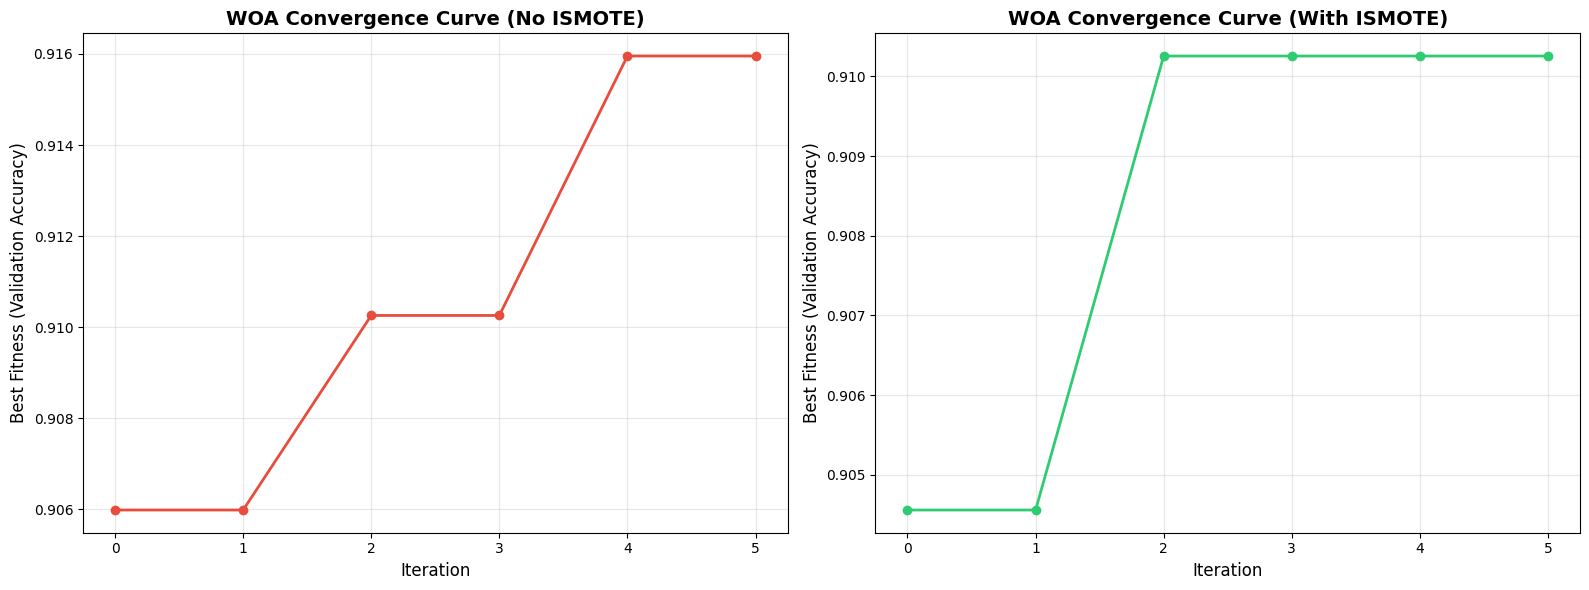

In [ ]:
# ============================================================================
# PLOT WOA CONVERGENCE CURVES
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: WOA Convergence (No ISMOTE)
axes[0].plot(range(len(fitness_hist_no_ismote)), fitness_hist_no_ismote,
             marker='o', linewidth=2, markersize=6, color='#e74c3c')
axes[0].set_title('WOA Convergence Curve (No ISMOTE)', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Best Fitness (Validation Accuracy)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Plot 2: WOA Convergence (With ISMOTE)
axes[1].plot(range(len(fitness_hist_with_ismote)), fitness_hist_with_ismote,
             marker='o', linewidth=2, markersize=6, color='#2ecc71')
axes[1].set_title('WOA Convergence Curve (With ISMOTE)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('Best Fitness (Validation Accuracy)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

EVALUATE ALL MODELS

In [ ]:
# ============================================================================
# EVALUATE ALL MODELS
# ============================================================================

# Predictions
y_pred_cnn_no_ismote = np.argmax(model_cnn_no_ismote.predict(X_test, verbose=0), axis=1)
y_pred_cnn_with_ismote = np.argmax(model_cnn_with_ismote.predict(X_test, verbose=0), axis=1)
y_pred_cnn_woa_no_ismote = np.argmax(model_cnn_woa_no_ismote.predict(X_test, verbose=0), axis=1)
y_pred_cnn_woa_with_ismote = np.argmax(model_cnn_woa_with_ismote.predict(X_test, verbose=0), axis=1)

# Calculate metrics for all models
models_results = {}

for model_name, y_pred in [
    ("CNN (No ISMOTE)", y_pred_cnn_no_ismote),
    ("CNN (With ISMOTE)", y_pred_cnn_with_ismote),
    ("CNN+WOA (No ISMOTE)", y_pred_cnn_woa_no_ismote),
    ("CNN+WOA (With ISMOTE)", y_pred_cnn_woa_with_ismote)
]:
    models_results[model_name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average="macro", zero_division=0),
        'recall': recall_score(y_test, y_pred, average="macro", zero_division=0),
        'f1': f1_score(y_test, y_pred, average="macro", zero_division=0),
        'predictions': y_pred
    }

# Display results
print("\n" + "="*70)
print("MODEL COMPARISON - TEST SET PERFORMANCE")
print("="*70)

comparison_df = pd.DataFrame(models_results).T
comparison_df.columns = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Predictions']
comparison_df = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']]

print(comparison_df.to_string())

# Highlight best performers
print("\n" + "-"*70)
print("BEST PERFORMERS:")
print("-"*70)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    best_model = comparison_df[metric].idxmax()
    best_value = comparison_df[metric].max()
    print(f"{metric:<12}: {best_model:<25} ({best_value:.4f})")


MODEL COMPARISON - TEST SET PERFORMANCE
                       Accuracy Precision    Recall  F1-Score
CNN (No ISMOTE)        0.908054  0.767028   0.76408  0.765535
CNN (With ISMOTE)       0.90948   0.76739  0.791936    0.7766
CNN+WOA (No ISMOTE)    0.905916   0.79189  0.712644  0.731917
CNN+WOA (With ISMOTE)  0.888097  0.736698  0.751693  0.740315

----------------------------------------------------------------------
BEST PERFORMERS:
----------------------------------------------------------------------
Accuracy    : CNN (With ISMOTE)         (0.9095)
Precision   : CNN+WOA (No ISMOTE)       (0.7919)
Recall      : CNN (With ISMOTE)         (0.7919)
F1-Score    : CNN (With ISMOTE)         (0.7766)


DETAILED CLASSIFICATION REPORTS

In [ ]:
# ============================================================================
# DETAILED CLASSIFICATION REPORTS
# ============================================================================

print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORTS")
print("="*70)

for model_name, results in models_results.items():
    print(f"\n{model_name}:")
    print("-" * 70)
    print(classification_report(y_test, results['predictions'], target_names=class_names))


DETAILED CLASSIFICATION REPORTS

CNN (No ISMOTE):
----------------------------------------------------------------------
              precision    recall  f1-score   support

       cubic       0.98      0.98      0.98       975
  monoclinic       0.76      0.76      0.76       174
orthorhombic       0.77      0.76      0.77       201
  tetragonal       0.56      0.55      0.55        53

    accuracy                           0.91      1403
   macro avg       0.77      0.76      0.77      1403
weighted avg       0.91      0.91      0.91      1403


CNN (With ISMOTE):
----------------------------------------------------------------------
              precision    recall  f1-score   support

       cubic       0.98      0.98      0.98       975
  monoclinic       0.78      0.78      0.78       174
orthorhombic       0.81      0.75      0.78       201
  tetragonal       0.50      0.66      0.57        53

    accuracy                           0.91      1403
   macro avg       0.77   

CONFUSION MATRICES

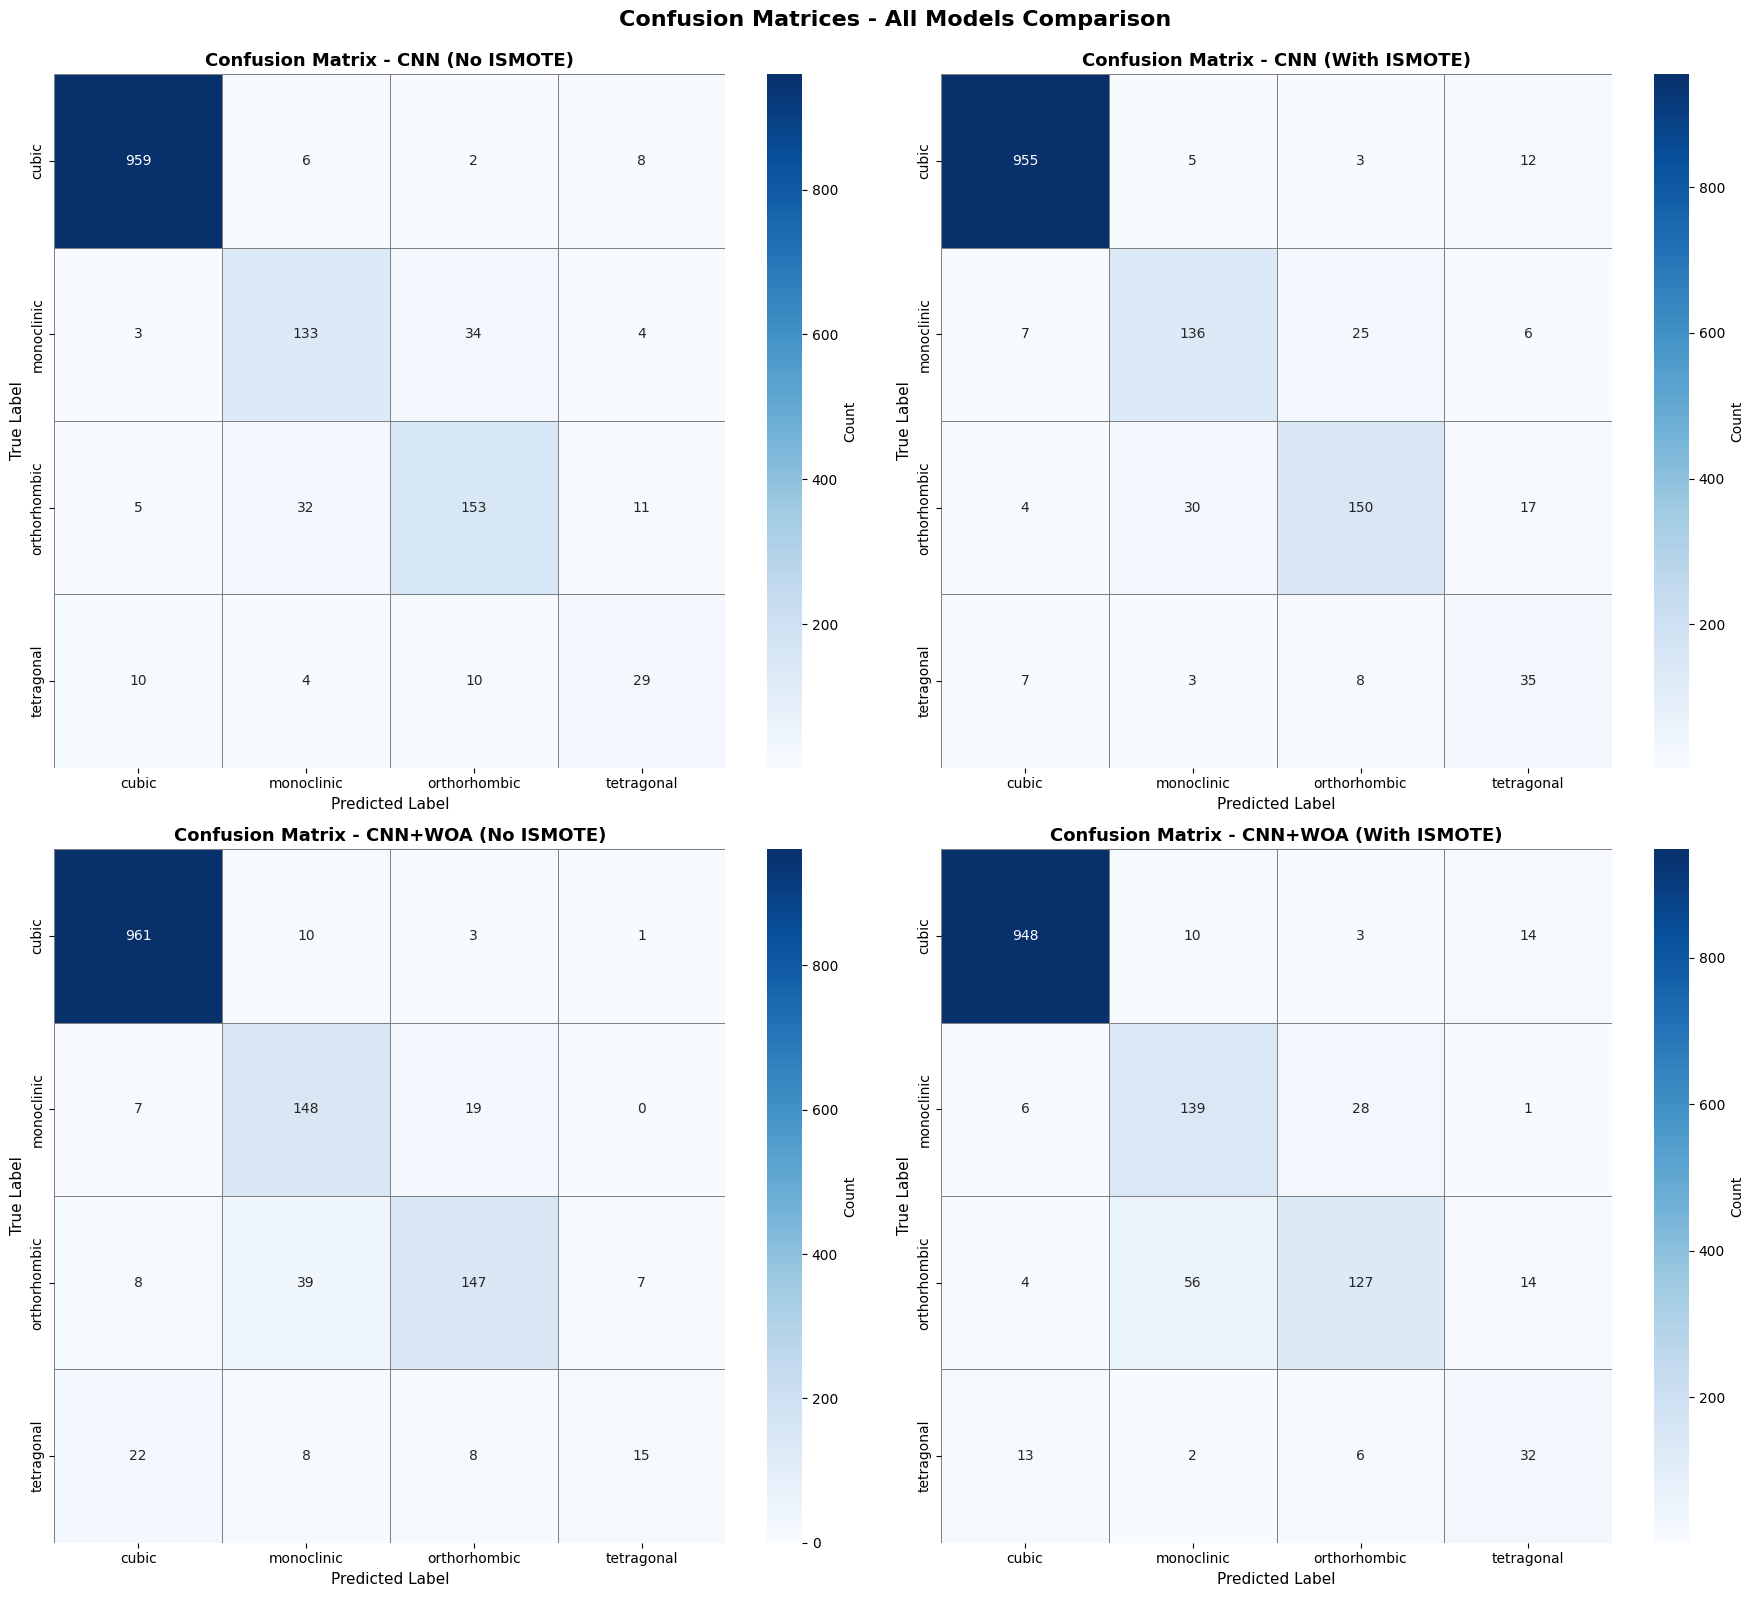

In [ ]:
# ============================================================================
# CONFUSION MATRICES
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.ravel()

for idx, (model_name, results) in enumerate(models_results.items()):
    cm = confusion_matrix(y_test, results['predictions'])

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'}, linewidths=0.5, linecolor='gray',
                ax=axes[idx])

    axes[idx].set_title(f'Confusion Matrix - {model_name}', fontweight='bold', fontsize=13)
    axes[idx].set_xlabel('Predicted Label', fontsize=11)
    axes[idx].set_ylabel('True Label', fontsize=11)

plt.suptitle('Confusion Matrices - All Models Comparison', fontweight='bold', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

PER-CLASS ACCURACY COMPARISON


PER-CLASS ACCURACY COMPARISON
              CNN (No ISMOTE)  CNN (With ISMOTE)  CNN+WOA (No ISMOTE)  CNN+WOA (With ISMOTE)
cubic                0.983590           0.979487             0.985641               0.972308
monoclinic           0.764368           0.781609             0.850575               0.798851
orthorhombic         0.761194           0.746269             0.731343               0.631841
tetragonal           0.547170           0.660377             0.283019               0.603774


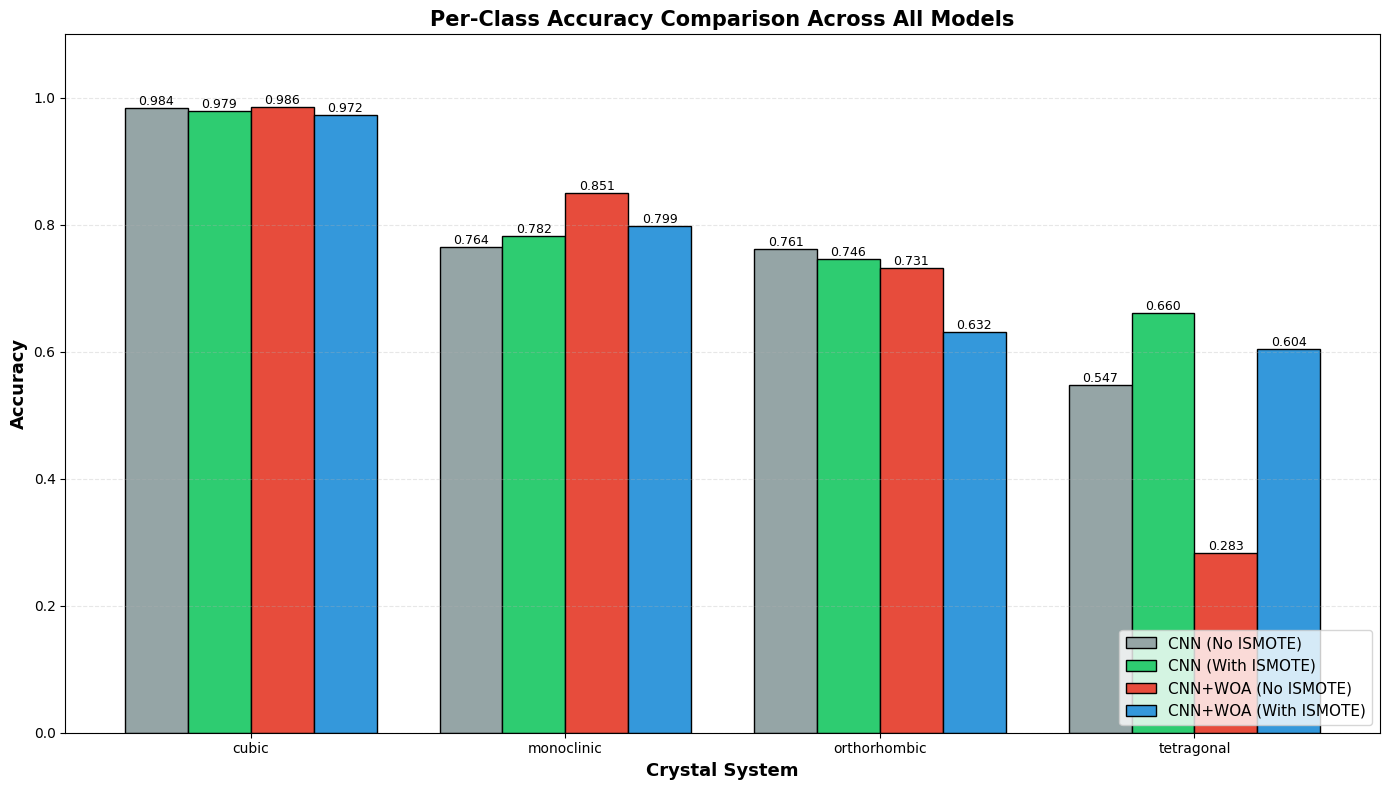

In [ ]:
# ============================================================================
# PER-CLASS ACCURACY COMPARISON
# ============================================================================

print("\n" + "="*70)
print("PER-CLASS ACCURACY COMPARISON")
print("="*70)

per_class_results = {}

for model_name, results in models_results.items():
    cm = confusion_matrix(y_test, results['predictions'])
    per_class_acc = []

    for i in range(len(class_names)):
        if cm[i].sum() > 0:
            per_class_acc.append(cm[i, i] / cm[i].sum())
        else:
            per_class_acc.append(0.0)

    per_class_results[model_name] = per_class_acc

# Create DataFrame
per_class_df = pd.DataFrame(per_class_results, index=class_names)
print(per_class_df.to_string())

# Visualize per-class accuracy
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(class_names))
width = 0.2

colors = ['#95a5a6', '#2ecc71', '#e74c3c', '#3498db']

for idx, (model_name, color) in enumerate(zip(per_class_results.keys(), colors)):
    offset = width * (idx - 1.5)
    bars = ax.bar(x + offset, per_class_results[model_name], width,
                  label=model_name, color=color, edgecolor='black', linewidth=1)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Crystal System', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax.set_title('Per-Class Accuracy Comparison Across All Models', fontweight='bold', fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

FEATURE EXTRACTION AND t-SNE VISUALIZATION

In [ ]:
# ============================================================================
# FEATURE EXTRACTION AND t-SNE VISUALIZATION
# ============================================================================

def extract_cnn_features(model, X_data):
    """Extract features from feature layer"""
    if len(X_data.shape) == 2:
        X_data = X_data[..., np.newaxis]
    feature_layer = model.get_layer("feature_layer")
    feat_model = Model(inputs=model.input, outputs=feature_layer.output)
    return feat_model.predict(X_data, verbose=0, batch_size=32)

print("\n" + "="*70)
print("EXTRACTING FEATURES FOR t-SNE VISUALIZATION")
print("="*70)

# Extract features from all models
features_cnn_no_ismote = extract_cnn_features(model_cnn_no_ismote, X_test_raw)
features_cnn_with_ismote = extract_cnn_features(model_cnn_with_ismote, X_test_raw)
features_cnn_woa_no_ismote = extract_cnn_features(model_cnn_woa_no_ismote, X_test_raw)
features_cnn_woa_with_ismote = extract_cnn_features(model_cnn_woa_with_ismote, X_test_raw)

print("✓ Feature extraction complete for all models!")


EXTRACTING FEATURES FOR t-SNE VISUALIZATION
✓ Feature extraction complete for all models!


t-SNE VISUALIZATION FOR ALL MODELS

In [ ]:
# ============================================================================
# t-SNE VISUALIZATION FOR ALL MODELS
# ============================================================================

print("\n" + "="*70)
print("GENERATING t-SNE VISUALIZATIONS")
print("="*70)

# Apply t-SNE to all feature sets
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000, verbose=0)

print("Applying t-SNE to CNN (No ISMOTE) features...")
X_tsne_cnn_no_ismote = tsne.fit_transform(features_cnn_no_ismote)

print("Applying t-SNE to CNN (With ISMOTE) features...")
X_tsne_cnn_with_ismote = tsne.fit_transform(features_cnn_with_ismote)

print("Applying t-SNE to CNN+WOA (No ISMOTE) features...")
X_tsne_cnn_woa_no_ismote = tsne.fit_transform(features_cnn_woa_no_ismote)

print("Applying t-SNE to CNN+WOA (With ISMOTE) features...")
X_tsne_cnn_woa_with_ismote = tsne.fit_transform(features_cnn_woa_with_ismote)

print("✓ t-SNE transformation complete for all models!")


GENERATING t-SNE VISUALIZATIONS
Applying t-SNE to CNN (No ISMOTE) features...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Applying t-SNE to CNN (With ISMOTE) features...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Applying t-SNE to CNN+WOA (No ISMOTE) features...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Applying t-SNE to CNN+WOA (With ISMOTE) features...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


✓ t-SNE transformation complete for all models!


PLOT t-SNE VISUALIZATIONS

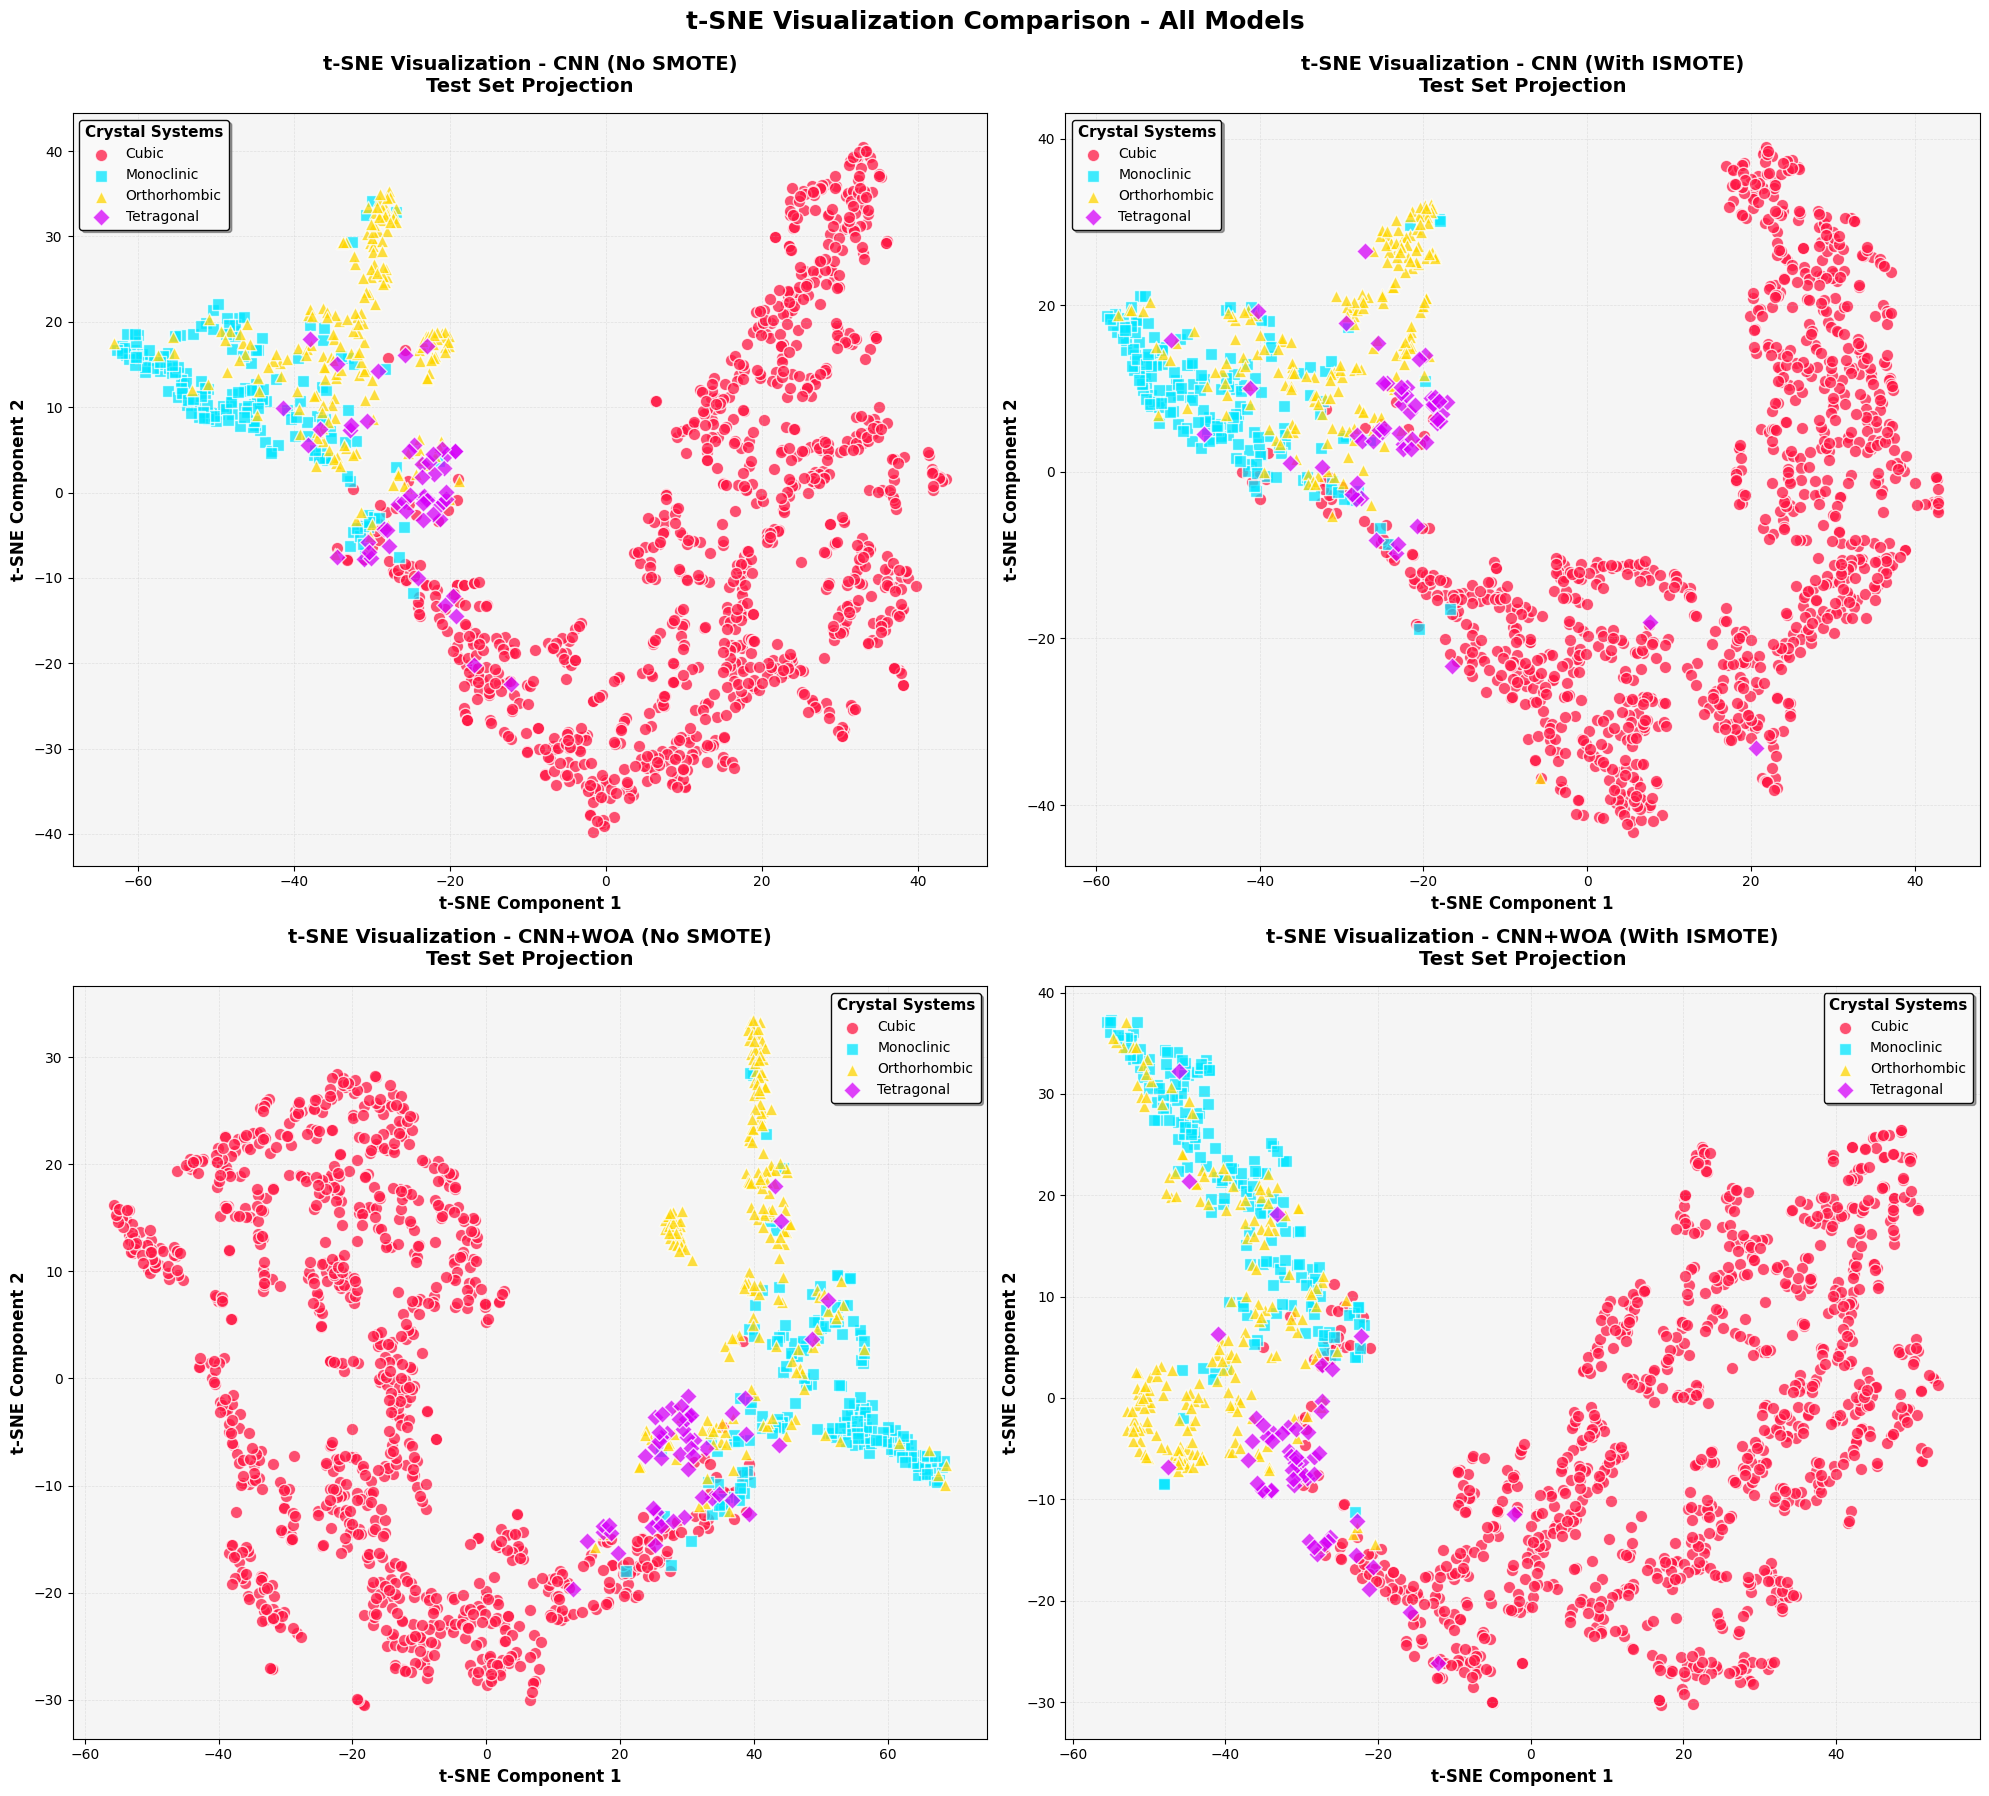


✓ t-SNE visualizations complete!
✓ Visualized 1403 test samples for each model


In [ ]:
# ============================================================================
# PLOT t-SNE VISUALIZATIONS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(20, 18))
axes = axes.ravel()

# Bright and distinct color palette
colors_bright = [
    '#FF1744',  # Bright Red - Cubic
    '#00E5FF',  # Bright Cyan - Monoclinic
    '#FFD600',  # Bright Yellow - Orthorhombic
    '#D500F9'   # Bright Purple - Tetragonal
]

markers = ['o', 's', '^', 'D']  # circle, square, triangle, diamond

tsne_data = [
    (X_tsne_cnn_no_ismote, "CNN (No SMOTE)"),
    (X_tsne_cnn_with_ismote, "CNN (With ISMOTE)"),
    (X_tsne_cnn_woa_no_ismote, "CNN+WOA (No SMOTE)"),
    (X_tsne_cnn_woa_with_ismote, "CNN+WOA (With ISMOTE)")
]

for idx, (X_tsne, title) in enumerate(tsne_data):
    ax = axes[idx]

    for i, name in enumerate(class_names):
        mask = (y_test == i)
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=colors_bright[i],
                   label=name.capitalize(),
                   s=80,
                   alpha=0.75,
                   edgecolors='white',
                   linewidths=1.0,
                   marker=markers[i])

    ax.set_title(f't-SNE Visualization - {title}\nTest Set Projection',
                 fontweight='bold', fontsize=14, pad=15)
    ax.set_xlabel('t-SNE Component 1', fontsize=12, fontweight='bold')
    ax.set_ylabel('t-SNE Component 2', fontsize=12, fontweight='bold')

    legend = ax.legend(fontsize=10, loc='best', framealpha=0.95,
                       edgecolor='black', fancybox=True, shadow=True)
    legend.set_title('Crystal Systems', prop={'size': 11, 'weight': 'bold'})

    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_facecolor('#F5F5F5')

plt.suptitle('t-SNE Visualization Comparison - All Models',
            fontweight='bold', fontsize=18, y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ t-SNE visualizations complete!")
print(f"✓ Visualized {len(X_test)} test samples for each model")

TRAINING HISTORY COMPARISON

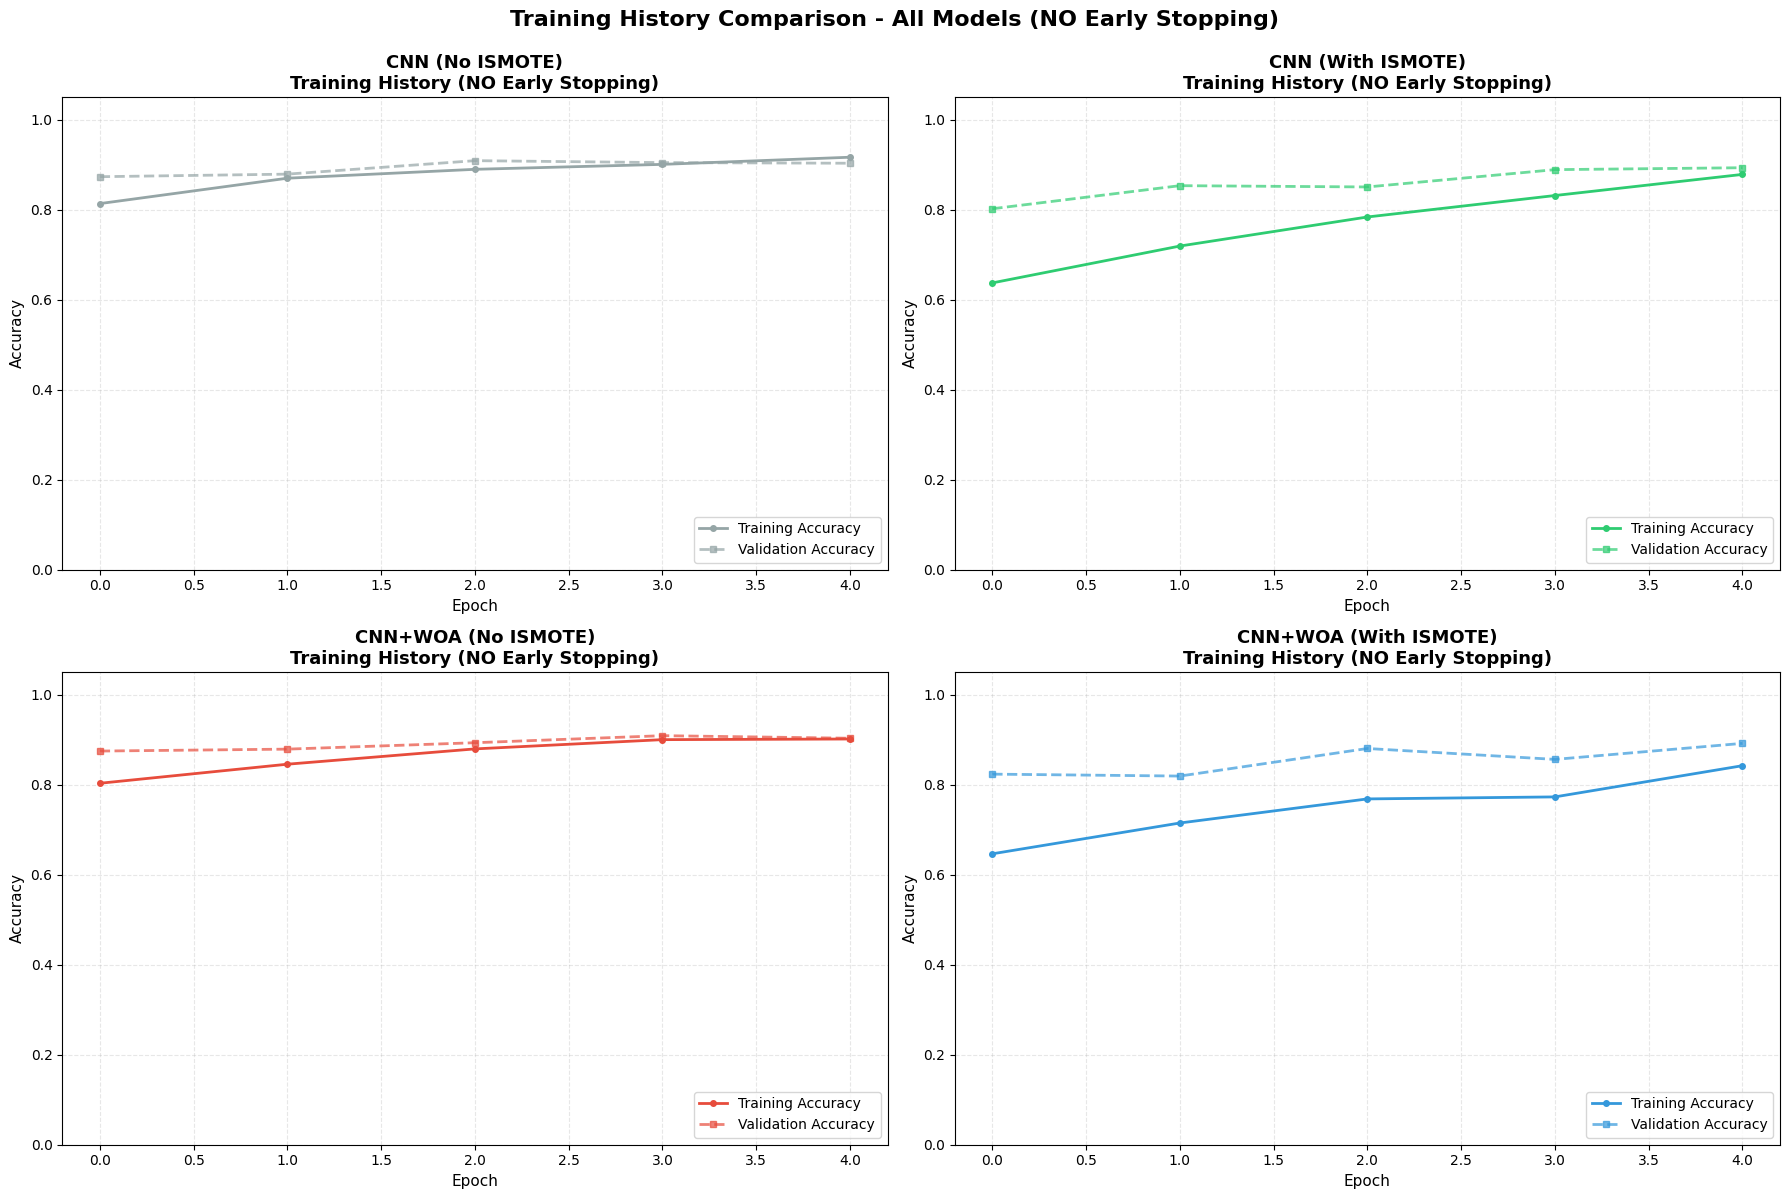

In [ ]:
# ============================================================================
# TRAINING HISTORY COMPARISON
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

histories = [
    (history_cnn_no_ismote, "CNN (No ISMOTE)", '#95a5a6'),
    (history_cnn_with_ismote, "CNN (With ISMOTE)", '#2ecc71'),
    (history_cnn_woa_no_ismote, "CNN+WOA (No ISMOTE)", '#e74c3c'),
    (history_cnn_woa_with_ismote, "CNN+WOA (With ISMOTE)", '#3498db')
]

for idx, (history, title, color) in enumerate(histories):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]

    # Plot training and validation accuracy
    ax.plot(history.history['accuracy'], label='Training Accuracy',
            linewidth=2, color=color, linestyle='-', marker='o', markersize=4)
    ax.plot(history.history['val_accuracy'], label='Validation Accuracy',
            linewidth=2, color=color, linestyle='--', marker='s', markersize=4, alpha=0.7)

    ax.set_title(f'{title}\nTraining History (NO Early Stopping)', fontweight='bold', fontsize=13)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(0, 1.05)

plt.suptitle('Training History Comparison - All Models (NO Early Stopping)',
            fontweight='bold', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

FINAL SUMMARY AND RECOMMENDATIONS

In [ ]:
# ============================================================================
# FINAL SUMMARY AND RECOMMENDATIONS
# ============================================================================

print("\n" + "="*70)
print("FINAL SUMMARY AND RECOMMENDATIONS")
print("="*70)

# Find overall best model
best_model_name = comparison_df['Accuracy'].idxmax()
best_accuracy = comparison_df['Accuracy'].max()

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Test Accuracy: {best_accuracy:.4f}")
print(f"   Test F1-Score: {comparison_df.loc[best_model_name, 'F1-Score']:.4f}")

print("\n" + "-"*70)
print("KEY FINDINGS:")
print("-"*70)

# Compare SMOTE effect
cnn_improvement = (models_results['CNN (With ISMOTE)']['accuracy'] -
                  models_results['CNN (No ISMOTE)']['accuracy'])
woa_improvement = (models_results['CNN+WOA (With ISMOTE)']['accuracy'] -
                  models_results['CNN+WOA (No ISMOTE)']['accuracy'])

print(f"1. SMOTE Impact on CNN:")
print(f"   Accuracy change: {cnn_improvement:+.4f} ({cnn_improvement*100:+.2f}%)")

print(f"\n2. SMOTE Impact on CNN+WOA:")
print(f"   Accuracy change: {woa_improvement:+.4f} ({woa_improvement*100:+.2f}%)")

# Compare WOA effect
woa_effect_no_smote = (models_results['CNN+WOA (No ISMOTE)']['accuracy'] -
                       models_results['CNN (No ISMOTE)']['accuracy'])
woa_effect_with_smote = (models_results['CNN+WOA (With ISMOTE)']['accuracy'] -
                         models_results['CNN (With ISMOTE)']['accuracy'])

print(f"\n3. WOA Optimization Impact (No SMOTE):")
print(f"   Accuracy change: {woa_effect_no_smote:+.4f} ({woa_effect_no_smote*100:+.2f}%)")

print(f"\n4. WOA Optimization Impact (With SMOTE):")
print(f"   Accuracy change: {woa_effect_with_smote:+.4f} ({woa_effect_with_smote*100:+.2f}%)")

print("\n" + "="*70)
print("TRAINING CONFIGURATION:")
print("="*70)
print(f"✓ Epochs: {EPOCHS_FINAL}")
print(f"✓ Early Stopping: DISABLED")
print(f"✓ Data Split: 70% Train / 10% Validation / 20% Test")
print(f"✓ SMOTE Applied: Training data only")

print("\n" + "="*70)
print("✓ EXPERIMENT COMPLETE!")
print("="*70)


FINAL SUMMARY AND RECOMMENDATIONS

🏆 BEST MODEL: CNN (With ISMOTE)
   Test Accuracy: 0.9095
   Test F1-Score: 0.7766

----------------------------------------------------------------------
KEY FINDINGS:
----------------------------------------------------------------------
1. SMOTE Impact on CNN:
   Accuracy change: +0.0014 (+0.14%)

2. SMOTE Impact on CNN+WOA:
   Accuracy change: -0.0178 (-1.78%)

3. WOA Optimization Impact (No SMOTE):
   Accuracy change: -0.0021 (-0.21%)

4. WOA Optimization Impact (With SMOTE):
   Accuracy change: -0.0214 (-2.14%)

TRAINING CONFIGURATION:
✓ Epochs: 5
✓ Early Stopping: DISABLED
✓ Data Split: 70% Train / 10% Validation / 20% Test
✓ SMOTE Applied: Training data only

✓ EXPERIMENT COMPLETE!
